# VitaMetrics - Product and Insights Analysis

[Zion Oluwasegun](https://bit.ly/ZionTheAnalyst)



## DATA CLEANING

### Data Loading & Initial Exploration

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

In [ ]:
# File paths
USER_PROFILES_PATH = r'Datasets\original\user_profiles.csv'
APP_EVENTS_PATH = r'Datasets\original\app_events.csv'
HEALTH_OUTCOMES_PATH = r'Datasets\original\health_outcomes.csv'

In [4]:
# Load user profiles
try:
    users = pd.read_csv(USER_PROFILES_PATH)
    print(f"user_profiles.csv loaded: {len(users)} users")
except Exception as e:
    print(f"Could not load user_profiles.csv - check path")
    print(f"Error: {e}")
    users = None

# Load app events
try:
    events = pd.read_csv(APP_EVENTS_PATH)
    print(f"app_events.csv loaded: {len(events):,} events")
except Exception as e:
    print(f"Could not load app_events.csv - check path")
    print(f"Error: {e}")
    events = None

# Load health outcomes
try:
    outcomes = pd.read_csv(HEALTH_OUTCOMES_PATH)
    print(f"health_outcomes.csv loaded: {len(outcomes)} readings")
except Exception as e:
    print(f"Could not load health_outcomes.csv - check path")
    print(f"Error: {e}")
    outcomes = None

user_profiles.csv loaded: 750 users
app_events.csv loaded: 61,214 events
health_outcomes.csv loaded: 2196 readings


In [5]:
# Keep original copies for reference
users_original = users.copy()
events_original = events.copy()
outcomes_original = outcomes.copy()

In [6]:
if users is not None:
    print("\n--- USER PROFILES ---")
    print(f"Shape: {users.shape}")
    print(f"Columns: {list(users.columns)}")
    print(f"\nDuplicate Users: {users.duplicated(subset='user_id').sum()}")
    print(f"Missing values:\n{users.isnull().sum()}")
    print(f"\nMarkets: {users['market'].value_counts().to_dict()}")
    print(f"Gender: {users['gender'].value_counts().to_dict()}")
    print(f"Subscription tiers: {users['subscription_tier'].value_counts().to_dict()}")
    print(f"Referral sources (raw): {users['referral_source'].value_counts().to_dict()}")
    print(f"\nDate range: {users['signup_date'].min()} to {users['signup_date'].max()}")


--- USER PROFILES ---
Shape: (750, 8)
Columns: ['user_id', 'signup_date', 'market', 'age_band', 'gender', 'height_cm', 'subscription_tier', 'referral_source']

Duplicate Users: 0
Missing values:
user_id               0
signup_date           0
market                0
age_band             45
gender               30
height_cm             0
subscription_tier     0
referral_source      59
dtype: int64

Markets: {'Nigeria': 362, 'United Kingdom': 234, 'UAE': 154}
Gender: {'Male': 352, 'Female': 326, 'Prefer not to say': 42}
Subscription tiers: {'Free': 313, 'Basic': 280, 'Premium': 157}
Referral sources (raw): {'Organic Search': 133, 'Social Media': 114, 'Referral': 82, 'Paid Ad': 81, 'organic_search': 45, 'referral': 44, 'Direct': 41, 'social media': 32, 'paid_ad': 28, 'Social media': 26, 'organic search': 25, 'PaidAd': 23, 'direct': 17}

Date range: 2024-01-01 to 2024-04-13


In [7]:
if events is not None:
    print("\n--- APP EVENTS ---")
    print(f"Shape: {events.shape}")
    print(f"Columns: {list(events.columns)}")
    
    # Convert timestamp to datetime
    events['event_timestamp'] = pd.to_datetime(events['event_timestamp'])
    
    print(f"\nDate range: {events['event_timestamp'].min()} to {events['event_timestamp'].max()}")
    print(f"Unique users: {events['user_id'].nunique()}")
    print(f"Unique events: {events['event_name'].nunique()}")
    print(f"\nDuplicates: {events.duplicated().sum()}")
    
    print(f"\nTop 10 events by frequency:")
    print(events['event_name'].value_counts().head(10))
    
    # Check for orphaned events (users not in profiles)
    if users is not None:
        orphaned = ~events['user_id'].isin(users['user_id'])
        print(f"\nOrphaned events (user not in profiles): {orphaned.sum()}")


--- APP EVENTS ---
Shape: (61214, 4)
Columns: ['user_id', 'event_name', 'event_timestamp', 'event_metadata']

Date range: 2024-01-01 00:00:00 to 2024-05-03 00:00:00
Unique users: 750
Unique events: 19

Duplicates: 1493

Top 10 events by frequency:
event_name
app_open                  14495
dashboard_viewed          10306
food_insight_generated     7721
food_logged                7714
weight_logged              5369
food_insight_viewed        4648
readings_recorded          2622
ai_insight_generated       2606
ai_insight_viewed          1838
signup_flow_start           774
Name: count, dtype: int64

Orphaned events (user not in profiles): 0


In [8]:
if outcomes is not None:
    print("\n--- HEALTH OUTCOMES ---")
    print(f"Shape: {outcomes.shape}")
    print(f"Columns: {list(outcomes.columns)}")
    
    # Convert date
    outcomes['record_date'] = pd.to_datetime(outcomes['record_date'])
    
    print(f"\nDate range: {outcomes['record_date'].min()} to {outcomes['record_date'].max()}")
    print(f"Unique users: {outcomes['user_id'].nunique()}")
    
    print(f"\nData sources: {outcomes['data_source'].value_counts().to_dict()}")
    print(f"\nBody fat % null count: {outcomes['body_fat_pct'].isnull().sum()} ({outcomes['body_fat_pct'].isnull().sum()/len(outcomes)*100:.1f}%)")
    print(f"  - By data source:")
    print(outcomes.groupby('data_source')['body_fat_pct'].apply(lambda x: x.isnull().sum()))
    
    # Check for users not in profiles
    if users is not None:
        orphaned_outcomes = ~outcomes['user_id'].isin(users['user_id'])
        print(f"\nOrphaned outcomes (user not in profiles): {orphaned_outcomes.sum()}")


--- HEALTH OUTCOMES ---
Shape: (2196, 9)
Columns: ['user_id', 'record_date', 'week_number', 'weight_kg', 'body_fat_pct', 'bmi', 'bmi_category', 'body_fat_category', 'data_source']

Date range: 2024-01-01 00:00:00 to 2024-04-21 00:00:00
Unique users: 439

Data sources: {'device_sync': 1376, 'manual_log': 820}

Body fat % null count: 820 (37.3%)
  - By data source:
data_source
device_sync      0
manual_log     820
Name: body_fat_pct, dtype: int64

Orphaned outcomes (user not in profiles): 0


### Data Quality Issues To Address

#### Data Quality Issue #1: Inconsistent Referral Source Values

Upon inspection, I noticed that `referral_source` has inconsistent formatting:
- Capitalization varies: 'Organic Search' vs 'organic_search' vs 'organic search'
- Spacing varies: 'PaidAd' vs 'Paid Ad' vs 'paid_ad'
- Null values: There are some null values in the column
- Some have underscores, some have spaces, some are capitalized

This appears to be due to changes in how the dropdown was configured over time, or possibly manual entry in some cases.

In [9]:
print("Current referral_source values:")
print(users['referral_source'].value_counts())
print(f"\nTotal unique values: {users['referral_source'].nunique()}")

Current referral_source values:
referral_source
Organic Search    133
Social Media      114
Referral           82
Paid Ad            81
organic_search     45
referral           44
Direct             41
social media       32
paid_ad            28
Social media       26
organic search     25
PaidAd             23
direct             17
Name: count, dtype: int64

Total unique values: 13


**Solution:**
I will standardize all referral sources by:
1. Fill the Null values with "unknown"
2. Converting to lowercase
3. Replacing underscores and multiple spaces with single spaces
4. Removing leading/trailing spaces
5. Mapping to standard categories

**Recommendation for product team:**
- Enforce dropdown values at the database level (not user input)
- Implement data validation rules
- Run a one-time cleanup script to standardize historical data (for backward compatibility/integration)

In [10]:
# Fill nulls with 'unknown'
users['referral_source'] = users['referral_source'].fillna('unknown')

In [11]:
# Step 0: Insert space before Capital letters (handling 'PaidAd' -> 'Paid Ad')
# This regex looks for a Capital letter that is NOT at the start of the string
users['referral_source'] = users['referral_source'].str.replace(r'(?<!^)(?=[A-Z])', ' ', regex=True)

# Step 1: Convert to lowercase
users['referral_source'] = users['referral_source'].str.lower()

# Step 2: Replace underscores with spaces
users['referral_source'] = users['referral_source'].str.replace('_', ' ')

# Step 3: Remove extra spaces (multiple spaces → single space)
users['referral_source'] = users['referral_source'].str.replace(r'\s+', ' ', regex=True)

# Step 4: Remove leading/trailing spaces
users['referral_source'] = users['referral_source'].str.strip()

# Verify the fix
print("After cleaning:\n")
print(users['referral_source'].value_counts())
print(f"\nTotal unique values: {users['referral_source'].nunique()}")


After cleaning:

referral_source
organic search    203
social media      172
paid ad           132
referral          126
unknown            59
direct             58
Name: count, dtype: int64

Total unique values: 6


The cleanup reduced unique values from 13 to 6 standard categories:
- organic search
- social media
- referral
- paid ad
- direct
- unknown

#### Data Quality Issue #2: Null `gender` and `age_band` values

Upon inspection, I noticed that `gender` has 'Male', 'Female', 'Prefer not to say', and also some Null values, while for `age_band`, some users selected the band they fall in, and others did not. This appears to be due to manual entry or users skipping this part of the drop down form entirely. Considering 'Prefer not to say' is already an option, there shouldn't be null values in `gender` at least.

**Solution:**
I will flag these null values across the two columns instead of dropping them entirely. This is because demographics are not required for core product metrics (activation, retention, engagement). Dropping these users would reduce the sample size by ~10% and bias results toward users who completed full profile setup.

**Recommendation for product team:**
- Enforce dropdown values at the database level (not user input)
- Implement data validation rules
- Run a one-time cleanup script to standardize historical data (for backward compatibility/integration)

In [12]:
# create a flag for analysis
users['has_complete_demographics'] = (
    users['age_band'].notna() & 
    users['gender'].isin(['Male', 'Female', 'Prefer not to say'])
)

print(f"Users with complete demographics: {users['has_complete_demographics'].sum()} ({users['has_complete_demographics'].sum()/len(users)*100:.1f}%)")

Users with complete demographics: 675 (90.0%)


Generally, for missing values, here's the strategy:
    
- **age_band (45 missing, 6%):** Retained in dataset. These users will be excluded from age-based segmentation but included in overall funnel/retention analysis.
- **gender (30 missing, 4%):** Retained in dataset. These users will be excluded from gender-based analysis and body fat % validation.
- **referral_source (59 missing, 7.9%):** Filled with 'unknown' - likely represents direct traffic or uncaptured sources.

#### Data Quality Issue #3: Duplicate entries in `events` table

Upon inspection, I noticed that `events` has **1493** duplicate values. Given the `timestamp` column to be very precise to record seconds, it's possible some events were logged multiple times due to app glitches or retries. 

**Solution:**
I will keep one record per event but remove exact duplicates to avoid skewing frequency analyses.

In [13]:
# drop duplicates in app_events
events = events.drop_duplicates(keep='first')

#### Data Quality Issue #4: BMI Calculation Validation

BMI is calculated as: **BMI = weight_kg / (height_m)²**

I will validate that the `bmi` values in `health_outcomes` match this calculation 
using the `height_cm` from `user_profiles`.

**Expected behavior:**
- BMI should be calculated correctly
- Any discrepancies > 0.5 BMI points will be flagged for investigation

In [14]:
# Merge outcomes with user profiles to get height
outcomes_with_height = outcomes.merge(
    users[['user_id', 'height_cm']], 
    on='user_id', 
    how='left'
)

In [15]:
# Formula: weight_kg / (height_m)^2
outcomes_with_height['height_m'] = outcomes_with_height['height_cm'] / 100
outcomes_with_height['calculated_bmi'] = (
    outcomes_with_height['weight_kg'] / (outcomes_with_height['height_m'] ** 2)
).round(1)

# Compare with recorded BMI
outcomes_with_height['bmi_difference'] = (
    outcomes_with_height['bmi'] - outcomes_with_height['calculated_bmi']
).abs()
outcomes_with_height.head()

,user_id,record_date,week_number,weight_kg,body_fat_pct,bmi,bmi_category,body_fat_category,data_source,height_cm,height_m,calculated_bmi,bmi_difference
0,USR_0001,2024-04-12,0,84.7,36.9,34.6,Obese Class I,Obese,device_sync,156.4,1.564,34.6,0.0
1,USR_0002,2024-02-21,0,87.8,44.9,31.0,Obese Class I,Obese,device_sync,168.4,1.684,31.0,0.0
2,USR_0002,2024-02-28,1,86.7,44.6,30.6,Obese Class I,Obese,device_sync,168.4,1.684,30.6,0.0
3,USR_0002,2024-03-06,2,86.2,44.0,30.4,Obese Class I,Obese,device_sync,168.4,1.684,30.4,0.0
4,USR_0002,2024-03-13,3,84.8,43.4,29.9,Overweight,Obese,device_sync,168.4,1.684,29.9,0.0


In [16]:
# Flag discrepancies > 0.5
discrepancies = outcomes_with_height[outcomes_with_height['bmi_difference'] > 0.5]

print(f"Total health outcome records: {len(outcomes_with_height)}")
print(f"Records with BMI discrepancies (>0.5): {len(discrepancies)}")
print(f"Percentage: {len(discrepancies)/len(outcomes_with_height)*100:.2f}%")

if len(discrepancies) > 0:
    print("\nSample discrepancies:")
    display(discrepancies[['user_id', 'weight_kg', 'height_cm', 'bmi', 'calculated_bmi', 'bmi_difference']].head())
else:
    print("\nAll BMI values are calculated correctly")

Total health outcome records: 2196
Records with BMI discrepancies (>0.5): 0
Percentage: 0.00%

All BMI values are calculated correctly


#### Data Quality Issue #5: Body Fat % Data Integrity

**Expected behavior:**
- When `data_source = 'manual_log'`, `body_fat_pct` should be NULL (user cannot measure this manually)
- When `data_source = 'device_sync'`, `body_fat_pct` should have a value (measured by connected device)

I will check for violations of this rule.

In [17]:
# Expected: manual_log rows should have NULL body_fat_pct
manual_logs = outcomes[outcomes['data_source'] == 'manual_log']
manual_with_bodyfat = manual_logs[manual_logs['body_fat_pct'].notna()]

print(f"Total manual_log records: {len(manual_logs)}")
print(f"Manual logs with body_fat_pct (UNEXPECTED): {len(manual_with_bodyfat)}")
if len(manual_with_bodyfat) > 0:
    print("\nData integrity issue detected!")
    display(manual_with_bodyfat[['user_id', 'record_date', 'data_source', 'body_fat_pct']].head())
else:
    print("\nAll manual_log records correctly have NULL body_fat_pct")

Total manual_log records: 820
Manual logs with body_fat_pct (UNEXPECTED): 0

All manual_log records correctly have NULL body_fat_pct


In [18]:
# Check the reverse: device_sync should have body_fat_pct
device_syncs = outcomes[outcomes['data_source'] == 'device_sync']
device_missing_bodyfat = device_syncs[device_syncs['body_fat_pct'].isna()]

print(f"\nTotal device_sync records: {len(device_syncs)}")
print(f"Device syncs missing body_fat_pct: {len(device_missing_bodyfat)}")
print(f"Percentage: {len(device_missing_bodyfat)/len(device_syncs)*100:.1f}%")


Total device_sync records: 1376
Device syncs missing body_fat_pct: 0
Percentage: 0.0%


#### Data Quality Issue #6: BMI Category Classification

**WHO BMI Categories:**
- Underweight: < 18.5
- Normal: 18.5 – 24.9
- Overweight: 25.0 – 29.9
- Obese Class I: 30.0 – 34.9
- Obese Class II: 35.0 – 39.9
- Obese Class III: ≥ 40.0

I will validate that the `bmi_category` column matches these classifications.

In [19]:
def calculate_bmi_category(bmi):
    """
    Classify BMI according to WHO standards
    """
    if pd.isna(bmi):
        return None
    elif bmi < 18.5:
        return 'Underweight'
    elif bmi < 25.0:
        return 'Normal'
    elif bmi < 30.0:
        return 'Overweight'
    elif bmi < 35.0:
        return 'Obese Class I'
    elif bmi < 40.0:
        return 'Obese Class II'
    else:
        return 'Obese Class III'

# Apply the function
outcomes['calculated_bmi_category'] = outcomes['bmi'].apply(calculate_bmi_category)

# Compare with recorded category
bmi_category_mismatch = outcomes[
    outcomes['bmi_category'] != outcomes['calculated_bmi_category']
]

print(f"Total records with BMI: {outcomes['bmi'].notna().sum()}")
print(f"BMI category mismatches: {len(bmi_category_mismatch)}")
print(f"Percentage: {len(bmi_category_mismatch)/outcomes['bmi'].notna().sum()*100:.2f}%")

if len(bmi_category_mismatch) > 0:
    print("\nSample mismatches:")
    display(bmi_category_mismatch[['user_id', 'bmi', 'bmi_category', 'calculated_bmi_category']].head(10))
else:
    print("\nAll BMI categories are correctly classified")

Total records with BMI: 2196
BMI category mismatches: 0
Percentage: 0.00%

All BMI categories are correctly classified


In [20]:
# Drop the calculated category column since it's just for validation
outcomes = outcomes.drop(columns=['calculated_bmi_category'])

#### Data Quality Issue #7: Body Fat % Category Classification

**ACE Body Fat % Categories (gender-specific):**

**Male:**
- Essential Fat: < 6%
- Athletic: 6–13%
- Fitness: 14–17%
- Acceptable: 18–24%
- Obese: ≥ 25%

**Female:**
- Essential Fat: < 14%
- Athletic: 14–20%
- Fitness: 21–24%
- Acceptable: 25–31%
- Obese: ≥ 32%

I will validate that `body_fat_category` matches these classifications based on user gender.

In [21]:
# Define body fat category function
def calculate_body_fat_category(body_fat_pct, gender):
    """
    Classify body fat % according to ACE standards (gender-specific)
    """
    if pd.isna(body_fat_pct) or pd.isna(gender):
        return None
    
    if gender == 'Male':
        if body_fat_pct < 6:
            return 'Essential'
        elif body_fat_pct < 14:
            return 'Athletic'
        elif body_fat_pct < 18:
            return 'Fitness'
        elif body_fat_pct < 25:
            return 'Acceptable'
        else:
            return 'Obese'
    
    elif gender == 'Female':
        if body_fat_pct < 14:
            return 'Essential'
        elif body_fat_pct < 21:
            return 'Athletic'
        elif body_fat_pct < 25:
            return 'Fitness'
        elif body_fat_pct < 32:
            return 'Acceptable'
        else:
            return 'Obese'
    
    else:
        return None

# Merge with gender from user profiles
outcomes_with_gender = outcomes.merge(
    users[['user_id', 'gender']], 
    on='user_id', 
    how='left'
)

# Calculate body fat category
outcomes_with_gender['calculated_body_fat_category'] = outcomes_with_gender.apply(
    lambda row: calculate_body_fat_category(row['body_fat_pct'], row['gender']),
    axis=1
)

# Compare with recorded category (only for non-null body fat %)
body_fat_records = outcomes_with_gender[outcomes_with_gender['body_fat_pct'].notna()]
body_fat_mismatch = body_fat_records[
    body_fat_records['body_fat_category'] != body_fat_records['calculated_body_fat_category']
]

print(f"Total records with body_fat_pct: {len(body_fat_records)}")
print(f"Body fat category mismatches: {len(body_fat_mismatch)}")
print(f"Percentage: {len(body_fat_mismatch)/len(body_fat_records)*100:.2f}%")

if len(body_fat_mismatch) > 0:
    print("\nSample mismatches:")
    display(body_fat_mismatch[['user_id', 'gender', 'body_fat_pct', 'body_fat_category', 'calculated_body_fat_category']].head(10))
else:
    print("\nAll body fat categories are correctly classified")


Total records with body_fat_pct: 1376
Body fat category mismatches: 133
Percentage: 9.67%

Sample mismatches:


,user_id,gender,body_fat_pct,body_fat_category,calculated_body_fat_category
73,USR_0025,NaN,23.8,NaN,None
74,USR_0025,NaN,22.3,NaN,None
75,USR_0025,NaN,22.4,NaN,None
76,USR_0025,NaN,21.5,NaN,None
77,USR_0025,NaN,20.9,NaN,None
78,USR_0025,NaN,20.3,NaN,None
96,USR_0034,Prefer not to say,37.1,Obese,None
110,USR_0040,NaN,21.7,NaN,None
111,USR_0040,NaN,21.6,NaN,None
112,USR_0040,NaN,21.4,NaN,None


At a glance, it shows that the only values for `gender` recorded here are 'Prefer not to say' and Null values. I will check the excat values present.

In [22]:
# First, check what genders we have in the mismatch
print("Gender distribution in body_fat_mismatch:")
print(body_fat_mismatch['gender'].value_counts(dropna=False))

Gender distribution in body_fat_mismatch:
gender
NaN                  76
Prefer not to say    57
Name: count, dtype: int64


It is confirmed that the issue is only with respect to 'Prefer not to say' and null genders.

In [23]:
# Filter body_fat_records to only Male/Female before comparing
body_fat_records_with_gender = body_fat_records[
    body_fat_records['gender'].isin(['Male', 'Female'])
]

body_fat_mismatch_clean = body_fat_records_with_gender[
    body_fat_records_with_gender['body_fat_category'] != body_fat_records_with_gender['calculated_body_fat_category']
]

print(f"\nValidation Results (Male/Female only):")
print(f"Total records with body_fat_pct AND gender (Male/Female): {len(body_fat_records_with_gender)}")
print(f"Body fat category mismatches: {len(body_fat_mismatch_clean)}")
print(f"Percentage: {len(body_fat_mismatch_clean)/len(body_fat_records_with_gender)*100:.2f}%")

# Check how many records we excluded
excluded = body_fat_records[~body_fat_records['gender'].isin(['Male', 'Female'])]
print(f"\nExcluded from validation:")
print(f"- Null gender: {excluded['gender'].isna().sum()}")
print(f"- 'Prefer not to say': {(excluded['gender'] == 'Prefer not to say').sum()}")
print(f"Total excluded: {len(excluded)} ({len(excluded)/len(body_fat_records)*100:.1f}% of body fat records)")


Validation Results (Male/Female only):
Total records with body_fat_pct AND gender (Male/Female): 1243
Body fat category mismatches: 0
Percentage: 0.00%

Excluded from validation:
- Null gender: 76
- 'Prefer not to say': 57
Total excluded: 133 (9.7% of body fat records)


**Finding:**

Out of 1376 records with body_fat_pct:
- 1243 records have Male/Female gender (validated)
- 133 records have missing or "Prefer not to say" gender (excluded from validation)

**Why this matters:**
Body fat % categories are gender-specific according to ACE standards. Without knowing 
biological sex, we cannot validate the category classification for these users.

**Limitation:**
9.7% of body fat records cannot be validated due to missing/undisclosed gender. 
These records will be excluded from gender-segmented analysis in Part 2.

**Recommendation for product team:**
1. Make gender selection mandatory at signup (from dropdown: Male, Female, Prefer not to say)
2. Add "Prefer not to say" category with unisex body fat thresholds, or
3. Use the more conservative Female thresholds as default when gender is undisclosed

#### Data Quality Issue #8: Manual Log Validation

I will validate that manual weight_logged events correspond to manual_log outcomes.

In [24]:
# Get all manual weight_logged events
manual_weight_events = events[
    (events['event_name'] == 'weight_logged') & 
    (events['event_metadata'] == 'manual')
]

# Get all manual_log outcomes
manual_outcomes = outcomes[outcomes['data_source'] == 'manual_log']

print(f"Manual weight_logged events: {len(manual_weight_events)}")
print(f"manual_log outcome records: {len(manual_outcomes)}")

# Check if users who logged weight manually have corresponding outcome records
manual_weight_users = manual_weight_events['user_id'].unique()
manual_outcome_users = manual_outcomes['user_id'].unique()

users_with_event_but_no_outcome = set(manual_weight_users) - set(manual_outcome_users)
print(f"\nUsers with manual weight_logged event but no manual_log outcome: {len(users_with_event_but_no_outcome)}")

Manual weight_logged events: 5244
manual_log outcome records: 820

Users with manual weight_logged event but no manual_log outcome: 233


In [25]:
manual_outcomes.head()

,user_id,record_date,week_number,weight_kg,body_fat_pct,bmi,bmi_category,body_fat_category,data_source
12,USR_0010,2024-04-10,2,79.0,NaN,26.8,Overweight,NaN,manual_log
13,USR_0010,2024-04-17,3,78.6,NaN,26.7,Overweight,NaN,manual_log
14,USR_0012,2024-03-15,0,86.6,NaN,28.6,Overweight,NaN,manual_log
15,USR_0012,2024-03-22,1,86.1,NaN,28.4,Overweight,NaN,manual_log
16,USR_0013,2024-04-04,1,71.9,NaN,23.8,Normal,NaN,manual_log


##### Finding: Health Outcomes Table is a Sampled Dataset

**Discovery:**
While validating that manual weight_logged events correspond to manual_log outcomes, 
I found a significant discrepancy:

- Manual weight_logged events: **5,369**
- manual_log outcome records: **820** (15.3% of events)

**Example - USR_0001:**
- Events table: 11 manual weight logs + 3 device syncs between 4/12-4/27
- Outcomes table: 1 record (device_sync on 4/12)

**Interpretation:**
The `health_outcomes` table is not a transactional log of every reading - it's a 
**periodic snapshot dataset** (likely weekly, based on the `week_number` column).

This is appropriate for health outcomes analysis, where we care about trends over time, 
not individual daily fluctuations.

**Implication for Analysis:**
- Events table: Use for behavioral analysis (activation, retention, engagement)
- Outcomes table: Use for health trends analysis (12-week weight/body fat changes)
- Do NOT expect 1:1 mapping between weight_logged events and outcome records

------------------------------
#### Exploring the datasets again

After identified quality issues have been addressed, I'm looking for any remaining anomalies or patterns that could impact analysis. This is a sanity check to ensure our cleaning steps have resolved the major issues without introducing new ones. We will also look for any edge cases or unexpected distributions in the key variables after cleaning.

In [26]:
users.head()

,user_id,signup_date,market,age_band,gender,height_cm,subscription_tier,referral_source,has_complete_demographics
0,USR_0001,2024-04-12,UAE,55+,Female,156.4,Premium,organic search,True
1,USR_0002,2024-02-21,United Kingdom,18-24,Female,168.4,Basic,social media,True
2,USR_0003,2024-04-02,Nigeria,35-44,Female,154.3,Free,referral,True
3,USR_0004,2024-01-15,Nigeria,45-54,Female,164.6,Free,referral,True
4,USR_0005,2024-03-12,UAE,45-54,Female,162.0,Free,paid ad,True


In [27]:
print(f"Missing values:\n{users.isnull().sum()}")
users.dtypes

Missing values:
user_id                       0
signup_date                   0
market                        0
age_band                     45
gender                       30
height_cm                     0
subscription_tier             0
referral_source               0
has_complete_demographics     0
dtype: int64


user_id                       object
signup_date                   object
market                        object
age_band                      object
gender                        object
height_cm                    float64
subscription_tier             object
referral_source               object
has_complete_demographics       bool
dtype: object

In [28]:
outcomes.head()

,user_id,record_date,week_number,weight_kg,body_fat_pct,bmi,bmi_category,body_fat_category,data_source
0,USR_0001,2024-04-12,0,84.7,36.9,34.6,Obese Class I,Obese,device_sync
1,USR_0002,2024-02-21,0,87.8,44.9,31.0,Obese Class I,Obese,device_sync
2,USR_0002,2024-02-28,1,86.7,44.6,30.6,Obese Class I,Obese,device_sync
3,USR_0002,2024-03-06,2,86.2,44.0,30.4,Obese Class I,Obese,device_sync
4,USR_0002,2024-03-13,3,84.8,43.4,29.9,Overweight,Obese,device_sync


In [29]:
print(f"Missing values:\n{outcomes.isnull().sum()}")
outcomes.dtypes

Missing values:
user_id                0
record_date            0
week_number            0
weight_kg              0
body_fat_pct         820
bmi                    0
bmi_category           0
body_fat_category    896
data_source            0
dtype: int64


user_id                      object
record_date          datetime64[ns]
week_number                   int64
weight_kg                   float64
body_fat_pct                float64
bmi                         float64
bmi_category                 object
body_fat_category            object
data_source                  object
dtype: object

In [30]:
print(f"Missing values:\n{events.isnull().sum()}")
events.dtypes

Missing values:
user_id                0
event_name             0
event_timestamp        0
event_metadata     51686
dtype: int64


user_id                    object
event_name                 object
event_timestamp    datetime64[ns]
event_metadata             object
dtype: object

In [31]:
# Final summary of data cleaning results
print("="*80)
print("DATA CLEANING SUMMARY")
print("="*80)

print("\n[USER PROFILES]")
print(f"Original records: {len(users_original)}")
print(f"Records retained: {len(users)} ({len(users)/len(users_original)*100:.1f}%)")
print(f"  - Missing age_band: {users['age_band'].isna().sum()} (retained)")
print(f"  - Missing gender: {users['gender'].isna().sum()} (retained)")
print(f"  - Missing referral_source: filled with 'unknown'")
print("Cleaning applied: Standardized referral_source (lowercase, single spaces)")

print("\n[HEALTH OUTCOMES]")
print(f"Original records: {len(outcomes_original)}")
print(f"Records retained: {len(outcomes)} ({len(outcomes)/len(outcomes_original)*100:.1f}%)")
print(f"  - body_fat_pct nulls: {outcomes['body_fat_pct'].isna().sum()} (expected for manual_log)")
print(f"  - body_fat_category nulls: {outcomes['body_fat_category'].isna().sum()} (expected)")
print("Cleaning applied: None (nulls are by design)")

print("\n[APP EVENTS]")
print(f"Original records: {len(events_original)}")
print(f"Records retained: {len(events)} ({len(events)/len(events_original)*100:.1f}%)")
print(f"  - event_metadata nulls: {events['event_metadata'].isna().sum()} (expected)")
print(f"  - Duplicates dropped: {len(events_original) - len(events)}")
print("Cleaning applied: Duplicate events were dropped based on all columns to ensure accurate event counts")

print("\n[OVERALL]")
print(f"Total records across all tables: {len(users) + len(outcomes) + len(events)}")
print(f"Records dropped: {len(events_original) - len(events)}")
print(f"Data loss: {(len(events_original) - len(events))/len(events_original)*100:.1f}%")
print("="*80)

DATA CLEANING SUMMARY

[USER PROFILES]
Original records: 750
Records retained: 750 (100.0%)
  - Missing age_band: 45 (retained)
  - Missing gender: 30 (retained)
  - Missing referral_source: filled with 'unknown'
Cleaning applied: Standardized referral_source (lowercase, single spaces)

[HEALTH OUTCOMES]
Original records: 2196
Records retained: 2196 (100.0%)
  - body_fat_pct nulls: 820 (expected for manual_log)
  - body_fat_category nulls: 896 (expected)
Cleaning applied: None (nulls are by design)

[APP EVENTS]
Original records: 61214
Records retained: 59721 (97.6%)
  - event_metadata nulls: 51686 (expected)
  - Duplicates dropped: 1493
Cleaning applied: Duplicate events were dropped based on all columns to ensure accurate event counts

[OVERALL]
Total records across all tables: 62667
Records dropped: 1493
Data loss: 2.4%


### Store cleaned datasets for analysis

In [ ]:
# Save cleaned datasets
users.to_csv(r'Datasets\cleaned\user_profiles_clean.csv', index=False)
events.to_csv(r'Datasets\cleaned\app_events_clean.csv', index=False)
outcomes.to_csv(r'Datasets\cleaned\health_outcomes_clean.csv', index=False)

## QUESTIONS

### Loading The Cleaned Datasets

In [ ]:
# File paths for cleaned datasets
USER_PROFILES_PATH = r'Datasets\cleaned\user_profiles_clean.csv'
APP_EVENTS_PATH = r'Datasets\cleaned\app_events_clean.csv'
HEALTH_OUTCOMES_PATH = r'Datasets\cleaned\health_outcomes_clean.csv'

In [34]:
# Load user profiles
try:
    users = pd.read_csv(USER_PROFILES_PATH)
    print(f"✓ user_profiles_clean.csv loaded: {len(users)} users")
except Exception as e:
    print(f"✗ Could not load user_profiles_clean.csv - check path")
    print(f"Error: {e}")
    users = None

# Load app events
try:
    events = pd.read_csv(APP_EVENTS_PATH)
    print(f"✓ app_events_clean.csv loaded: {len(events):,} events")
except Exception as e:
    print(f"✗ Could not load app_events_clean.csv - check path")
    print(f"Error: {e}")
    events = None

# Load health outcomes
try:
    outcomes = pd.read_csv(HEALTH_OUTCOMES_PATH)
    print(f"✓ health_outcomes_clean.csv loaded: {len(outcomes)} readings")
except Exception as e:
    print(f"✗ Could not load health_outcomes_clean.csv - check path")
    print(f"Error: {e}")
    outcomes = None

✓ user_profiles_clean.csv loaded: 750 users
✓ app_events_clean.csv loaded: 59,721 events
✓ health_outcomes_clean.csv loaded: 2196 readings


### Part 1a: Activation Funnel Analysis

**Objective:** Map the signup flow and identify drop-off points

**Signup Flow Stages:**
1. signup_flow_start
2. signup_verification_start
3. signup_verification_complete
4. profile_setup_complete
5. signup_completed

I will calculate conversion rates at each stage and identify the biggest leakage points.

In [35]:
# Filter events to only signup-related actions
signup_event_names = [
    'signup_flow_start',
    'signup_verification_start',
    'signup_verification_failed',
    'signup_verification_complete',
    'profile_setup_complete',
    'signup_completed'
]

signup_events = events[events['event_name'].isin(signup_event_names)].copy()

display(signup_events.head(10))
print(f"\nTotal signup events: {len(signup_events)}")
print(f"Unique users in signup flow: {signup_events['user_id'].nunique()}")
print("\nEvent breakdown:")
print(signup_events['event_name'].value_counts())

,user_id,event_name,event_timestamp,event_metadata
0,USR_0001,signup_flow_start,2024-04-12 00:00:00,NaN
1,USR_0001,signup_verification_start,2024-04-12 00:00:34,NaN
2,USR_0001,signup_verification_complete,2024-04-12 00:00:58,NaN
3,USR_0001,profile_setup_complete,2024-04-12 00:07:58,NaN
4,USR_0001,signup_completed,2024-04-12 00:08:19,NaN
75,USR_0002,signup_flow_start,2024-02-21 00:00:00,NaN
76,USR_0002,signup_verification_start,2024-02-21 00:00:34,NaN
77,USR_0002,signup_verification_failed,2024-02-21 00:01:11,attempt_1
78,USR_0002,signup_verification_complete,2024-02-21 00:02:01,NaN
79,USR_0002,profile_setup_complete,2024-02-21 00:11:01,NaN



Total signup events: 3103
Unique users in signup flow: 750

Event breakdown:
event_name
signup_flow_start               750
signup_verification_start       687
signup_verification_complete    523
profile_setup_complete          455
signup_completed                439
signup_verification_failed      249
Name: count, dtype: int64


In [36]:
# Analyze user journeys through the signup flow
user_stages = signup_events.groupby('user_id')['event_name'].apply(list).reset_index()
user_stages.columns = ['user_id', 'events']
with pd.option_context('display.max_colwidth', None):
    display(user_stages.head(10))

,user_id,events
0,USR_0001,"[signup_flow_start, signup_verification_start, signup_verification_complete, profile_setup_complete, signup_completed]"
1,USR_0002,"[signup_flow_start, signup_verification_start, signup_verification_failed, signup_verification_complete, profile_setup_complete, signup_completed]"
2,USR_0003,"[signup_flow_start, signup_verification_start, signup_verification_failed, signup_verification_failed, signup_verification_failed]"
3,USR_0004,"[signup_flow_start, signup_verification_start, signup_verification_complete]"
4,USR_0005,"[signup_flow_start, signup_verification_start, signup_verification_failed, signup_verification_complete, profile_setup_complete, signup_completed]"
5,USR_0006,[signup_flow_start]
6,USR_0007,"[signup_flow_start, signup_verification_start, signup_verification_failed]"
7,USR_0008,"[signup_flow_start, signup_verification_start, signup_verification_failed, signup_verification_complete, profile_setup_complete, signup_completed]"
8,USR_0009,"[signup_flow_start, signup_verification_start]"
9,USR_0010,"[signup_flow_start, signup_verification_start, signup_verification_complete, profile_setup_complete, signup_completed]"


In [37]:
# Create flags for each stage
user_stages['stage_1_flow_start'] = user_stages['events'].apply(
    lambda x: 'signup_flow_start' in x
)
user_stages['stage_2_verification_start'] = user_stages['events'].apply(
    lambda x: 'signup_verification_start' in x
)
user_stages['stage_3_verification_complete'] = user_stages['events'].apply(
    lambda x: 'signup_verification_complete' in x
)
user_stages['stage_4_profile_setup'] = user_stages['events'].apply(
    lambda x: 'profile_setup_complete' in x
)
user_stages['stage_5_signup_complete'] = user_stages['events'].apply(
    lambda x: 'signup_completed' in x
)

# Also flag verification failures
user_stages['had_verification_failure'] = user_stages['events'].apply(
    lambda x: 'signup_verification_failed' in x
)

print("Sample user progression:")
display(user_stages.head())

Sample user progression:


,user_id,events,stage_1_flow_start,stage_2_verification_start,stage_3_verification_complete,stage_4_profile_setup,stage_5_signup_complete,had_verification_failure
0,USR_0001,"[signup_flow_start, signup_verification_start,...",True,True,True,True,True,False
1,USR_0002,"[signup_flow_start, signup_verification_start,...",True,True,True,True,True,True
2,USR_0003,"[signup_flow_start, signup_verification_start,...",True,True,False,False,False,True
3,USR_0004,"[signup_flow_start, signup_verification_start,...",True,True,True,False,False,False
4,USR_0005,"[signup_flow_start, signup_verification_start,...",True,True,True,True,True,True


In [38]:
# Count users at each stage
funnel_data = {
    'stage': [
        '1. Flow Start',
        '2. Verification Start',
        '3. Verification Complete',
        '4. Profile Setup',
        '5. Signup Complete'
    ],
    'users_reached': [
        user_stages['stage_1_flow_start'].sum(),
        user_stages['stage_2_verification_start'].sum(),
        user_stages['stage_3_verification_complete'].sum(),
        user_stages['stage_4_profile_setup'].sum(),
        user_stages['stage_5_signup_complete'].sum()
    ]
}

funnel = pd.DataFrame(funnel_data)
funnel.head()

,stage,users_reached
0,1. Flow Start,750
1,2. Verification Start,687
2,3. Verification Complete,523
3,4. Profile Setup,455
4,5. Signup Complete,439


In [39]:
# Calculate conversion rates and drop-offs
funnel['conversion_from_start'] = (funnel['users_reached'] / funnel['users_reached'].iloc[0] * 100).round(1)
funnel['users_dropped'] = funnel['users_reached'].diff().fillna(0).abs().astype(int)
funnel['drop_off_rate'] = (funnel['users_dropped'] / funnel['users_reached'].shift(1) * 100).fillna(0).round(1)

print("\n" + "="*70)
print("SIGNUP FUNNEL SUMMARY")
print("="*70)
display(funnel)
print("\n" + "="*70)

# Identify biggest leakage
biggest_drop = funnel.loc[funnel['users_dropped'].idxmax()]
print(f"\nBIGGEST LEAKAGE: {biggest_drop['stage']}")
print(f"       Drop-off: {biggest_drop['users_dropped']} users ({biggest_drop['drop_off_rate']}%)")

# Track verification failures
failed_users = user_stages['had_verification_failure'].sum()
print(f"\nVerification failures: {failed_users} users ({failed_users/len(user_stages)*100:.1f}%)")



SIGNUP FUNNEL SUMMARY


,stage,users_reached,conversion_from_start,users_dropped,drop_off_rate
0,1. Flow Start,750,100.0,0,0.0
1,2. Verification Start,687,91.6,63,8.4
2,3. Verification Complete,523,69.7,164,23.9
3,4. Profile Setup,455,60.7,68,13.0
4,5. Signup Complete,439,58.5,16,3.5




BIGGEST LEAKAGE: 3. Verification Complete
       Drop-off: 164 users (23.9%)

Verification failures: 214 users (28.5%)


In [40]:
# Merge user_stages with user_profiles to analyze by demographics
funnel_with_profile = user_stages.merge(users, on='user_id', how='left')
display(funnel_with_profile.head())

print("\n" + "="*70)
print("DROP-OFF PATTERNS BY SEGMENT")
print("="*70)

# By market
print("\n1. COMPLETION RATE BY MARKET:")
market_completion = funnel_with_profile.groupby('market')['stage_5_signup_complete'].agg(['sum', 'count'])
market_completion['completion_rate'] = (market_completion['sum'] / market_completion['count'] * 100).round(1)
market_completion = market_completion.sort_values('completion_rate', ascending=False)
display(market_completion)

# By referral source
print("\n2. COMPLETION RATE BY REFERRAL SOURCE:")
referral_completion = funnel_with_profile.groupby('referral_source')['stage_5_signup_complete'].agg(['sum', 'count'])
referral_completion['completion_rate'] = (referral_completion['sum'] / referral_completion['count'] * 100).round(1)
referral_completion = referral_completion.sort_values('completion_rate', ascending=False)
display(referral_completion)

# By subscription tier (for completed signups only)
print("\n3. USERS WHO COMPLETED - SUBSCRIPTION TIER DISTRIBUTION:")
completed_users = funnel_with_profile[funnel_with_profile['stage_5_signup_complete'] == True]
print(completed_users['subscription_tier'].value_counts())

,user_id,events,stage_1_flow_start,stage_2_verification_start,stage_3_verification_complete,stage_4_profile_setup,stage_5_signup_complete,had_verification_failure,signup_date,market,age_band,gender,height_cm,subscription_tier,referral_source,has_complete_demographics
0,USR_0001,"[signup_flow_start, signup_verification_start,...",True,True,True,True,True,False,2024-04-12,UAE,55+,Female,156.4,Premium,organic search,True
1,USR_0002,"[signup_flow_start, signup_verification_start,...",True,True,True,True,True,True,2024-02-21,United Kingdom,18-24,Female,168.4,Basic,social media,True
2,USR_0003,"[signup_flow_start, signup_verification_start,...",True,True,False,False,False,True,2024-04-02,Nigeria,35-44,Female,154.3,Free,referral,True
3,USR_0004,"[signup_flow_start, signup_verification_start,...",True,True,True,False,False,False,2024-01-15,Nigeria,45-54,Female,164.6,Free,referral,True
4,USR_0005,"[signup_flow_start, signup_verification_start,...",True,True,True,True,True,True,2024-03-12,UAE,45-54,Female,162.0,Free,paid ad,True



DROP-OFF PATTERNS BY SEGMENT

1. COMPLETION RATE BY MARKET:


,sum,count,completion_rate
market,,,
United Kingdom,144,234,61.5
Nigeria,210,362,58.0
UAE,85,154,55.2



2. COMPLETION RATE BY REFERRAL SOURCE:


,sum,count,completion_rate
referral_source,,,
referral,86,126,68.3
organic search,136,203,67.0
direct,36,58,62.1
social media,91,172,52.9
unknown,30,59,50.8
paid ad,60,132,45.5



3. USERS WHO COMPLETED - SUBSCRIPTION TIER DISTRIBUTION:
subscription_tier
Basic      167
Free       145
Premium    127
Name: count, dtype: int64


    market        date  failed_count
0  Nigeria  2024-01-02             2
1  Nigeria  2024-01-03             5
2  Nigeria  2024-01-04             1
3  Nigeria  2024-01-05             1
4  Nigeria  2024-01-06             1
5  Nigeria  2024-01-07             1
6  Nigeria  2024-01-08             4
7  Nigeria  2024-01-09             3
8  Nigeria  2024-01-11             1
9  Nigeria  2024-01-12             1


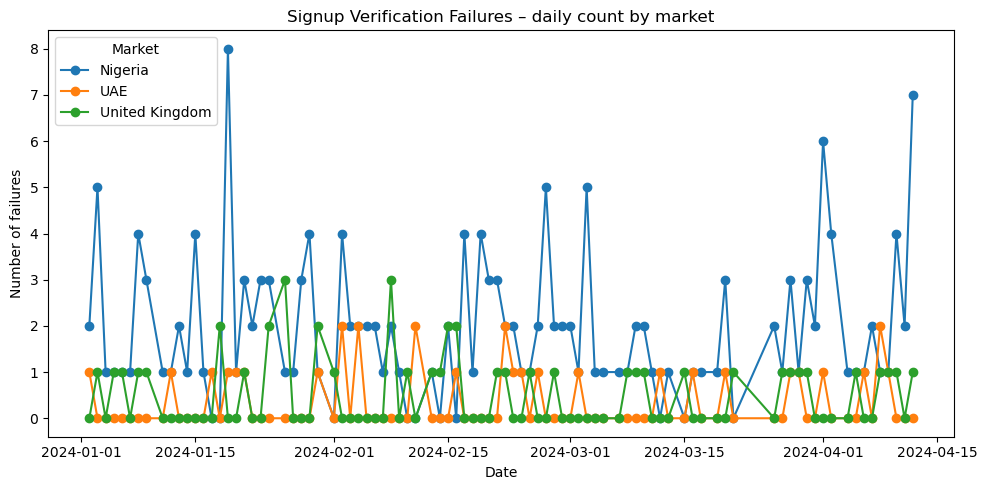

In [41]:
# look only at the failed‑verification events and bring in the user market
vfails = events[events['event_name'] == 'signup_verification_failed'].copy()
vfails = vfails.merge(users[['user_id','market']], on='user_id', how='left')

# ensure timestamp is datetime and extract date for grouping
vfails['event_timestamp'] = pd.to_datetime(vfails['event_timestamp'])
vfails['date'] = vfails['event_timestamp'].dt.date

# daily counts by market
trend = (vfails
         .groupby(['market','date'])
         .size()
         .reset_index(name='failed_count'))

# pivot so each market is a column for easy plotting
trend_pivot = trend.pivot(index='date', columns='market', values='failed_count').fillna(0)

# show the raw numbers too
print(trend.head(10))

# plot the time series
trend_pivot.plot(figsize=(10,5), marker='o')
plt.title('Signup Verification Failures – daily count by market')
plt.xlabel('Date')
plt.ylabel('Number of failures')
plt.legend(title='Market')
plt.tight_layout()

#### Deep Dive: Verification Failures

I noticed verification failures in the funnel. Let's investigate:
1. How many failures by market?
2. How many attempts do users make before giving up?
3. Do users who fail eventually complete signup?


In [42]:
# Verification failures by market
print("="*70)
print("VERIFICATION FAILURES BY MARKET")
print("="*70)

# Get all failed verification events
failed_verifications = events[events['event_name'] == 'signup_verification_failed'].copy()

# Merge with user market
failed_with_market = failed_verifications.merge(
    users[['user_id', 'market']], 
    on='user_id', 
    how='left'
)

# Count failures by market
failures_by_market = failed_with_market.groupby('market').agg({
    'user_id': 'nunique',  # Unique users who failed
    'event_name': 'count'   # Total failure events
}).reset_index()
failures_by_market.columns = ['market', 'unique_users_failed', 'total_failures']

# Calculate average failures per user
failures_by_market['avg_failures_per_user'] = (
    failures_by_market['total_failures'] / failures_by_market['unique_users_failed']
).round(1)

print(failures_by_market)

VERIFICATION FAILURES BY MARKET
           market  unique_users_failed  total_failures  avg_failures_per_user
0         Nigeria                  144             175                    1.2
1             UAE                   29              30                    1.0
2  United Kingdom                   41              44                    1.1


In [43]:
# Compare to total signups by market
signups_by_market = users.groupby('market')['user_id'].count().reset_index()
signups_by_market.columns = ['market', 'total_users']

market_failure_rate = failures_by_market.merge(signups_by_market, on='market')
market_failure_rate['failure_rate'] = (
    market_failure_rate['unique_users_failed'] / market_failure_rate['total_users'] * 100
).round(1)

print("\n\nFailure Rate by Market:")
display(market_failure_rate[['market', 'total_users', 'unique_users_failed', 'failure_rate']].sort_values('failure_rate', ascending=False))




Failure Rate by Market:


,market,total_users,unique_users_failed,failure_rate
0,Nigeria,362,144,39.8
1,UAE,154,29,18.8
2,United Kingdom,234,41,17.5


**Finding:**
- Nigeria has highest failure rate at 39.8%
- UK has lowest failure rate at 17.5%
- Hypothesis: SMS verification may not work well in Nigeria due to network issues

In [44]:
# Beyond signup_completed, what makes a user "activated"?

print("\n" + "="*70)
print("DEFINING 'FULLY ACTIVATED'")
print("="*70)

# Get users who completed signup
completed_signups = user_stages[user_stages['stage_5_signup_complete'] == True]['user_id'].unique()

print(f"\nUsers who completed signup: {len(completed_signups)}")

# Check activation actions within 7 days of signup
activation_actions = ['device_connected', 'readings_recorded', 'weight_logged']

# Get signup timestamps
signup_times = events[events['event_name'] == 'signup_completed'].groupby('user_id')['event_timestamp'].min()

# Get first activation action for each user
activation_events = events[events['event_name'].isin(activation_actions)]
first_activation = activation_events.groupby('user_id')['event_timestamp'].min()

# Merge and calculate time to activation
activation_df = pd.DataFrame({
    'user_id': signup_times.index,
    'signup_time': signup_times.values
})
activation_df = activation_df.merge(
    pd.DataFrame({'user_id': first_activation.index, 'first_action_time': first_activation.values}),
    on='user_id',
    how='left'
)
# Convert to datetime
activation_df['signup_time'] = pd.to_datetime(activation_df['signup_time'])
activation_df['first_action_time'] = pd.to_datetime(activation_df['first_action_time'])


# Calculate days to first action
activation_df['days_to_action'] = (
    (activation_df['first_action_time'] - activation_df['signup_time']).dt.total_seconds() / 86400
)

# Define activated: took action within 7 days
activation_df['is_activated'] = (activation_df['days_to_action'] <= 7) & (activation_df['days_to_action'].notna())

# Review activation results
activation_df.head()

activated_users = activation_df['is_activated'].sum()
print(f"\nUsers ACTIVATED (action within 7 days): {activated_users} ({activated_users/len(completed_signups)*100:.1f}%)")
print(f"Users NOT activated: {len(completed_signups) - activated_users} ({(len(completed_signups) - activated_users)/len(completed_signups)*100:.1f}%)")

print("\n\nActivation action breakdown (first 7 days):")
activated_user_ids = activation_df[activation_df['is_activated']]['user_id']
first_actions = events[
    (events['user_id'].isin(activated_user_ids)) & 
    (events['event_name'].isin(activation_actions))
]
print(first_actions['event_name'].value_counts())


DEFINING 'FULLY ACTIVATED'

Users who completed signup: 439

Users ACTIVATED (action within 7 days): 299 (68.1%)
Users NOT activated: 140 (31.9%)


Activation action breakdown (first 7 days):
event_name
weight_logged        4951
readings_recorded    2542
device_connected      257
Name: count, dtype: int64


**Definition:** "Fully Activated"

**Criteria:** User completed signup AND performed at least one of the following within 7 days:
- Connected a device
- Recorded health readings
- Logged weight manually

**Reasoning:**
Signup completion alone doesn't indicate engagement. A user who signs up but never 
logs data or connects a device isn't really "using" the product. The 7-day window 
captures the critical onboarding period.

**Result:** 68.1% of signups are fully activated by this definition.

### Part 1b: Retention Analysis

**Objective:** Measure how well the platform retains users after signup

**Retention Definition:**
- **D1 Retention:** User returns 1 day after signup (has app_open event on day 1)
- **D7 Retention:** User active during week 1 (days 1-7)
- **D14 Retention:** User active during week 2 (days 8-14)
- **D30 Retention:** User active during days 15-30

**Measurement Approach:** Cohort analysis by signup week


In [45]:
# Prepare retention data

# Get signup dates for all users
user_signups = users[['user_id', 'signup_date']].copy()
# Ensure signup_date is datetime
user_signups['signup_date'] = pd.to_datetime(user_signups['signup_date'])
user_signups['signup_week'] = user_signups['signup_date'].dt.to_period('W').astype(str)

# Get all app_open events
app_opens = events[events['event_name'] == 'app_open'].copy()

# Convert timestamp to datetime
app_opens['event_timestamp'] = pd.to_datetime(app_opens['event_timestamp'])

# Merge with signup dates
opens_with_signup = app_opens.merge(user_signups, on='user_id')

# Calculate days since signupfor each app_open event
opens_with_signup['days_since_signup'] = (
    (opens_with_signup['event_timestamp'] - opens_with_signup['signup_date']).dt.total_seconds() / 86400
)

print(f"Total app_open events: {len(app_opens)}")
print(f"Users with at least one app_open: {app_opens['user_id'].nunique()}")
# Added error handling for min/max in case the dataframe is empty
if not opens_with_signup.empty:
    print(f"\nDate range: {opens_with_signup['days_since_signup'].min():.1f} to {opens_with_signup['days_since_signup'].max():.1f} days")
else:
    print("No matching data found.")

Total app_open events: 14161
Users with at least one app_open: 438

Date range: 1.3 to 111.9 days


In [46]:
# Calculate retention for each user
retention_list = []

for user_id in user_signups['user_id']:
    user_data = opens_with_signup[opens_with_signup['user_id'] == user_id]
    
    if len(user_data) == 0:
        # No app opens after signup
        d1 = d7 = d14 = d30 = False
    else:
        days = user_data['days_since_signup'].values
        d1 = any((days >= 1) & (days < 2))
        d7 = any((days >= 1) & (days < 8))
        d14 = any((days >= 8) & (days < 15))
        d30 = any((days >= 15) & (days < 31))
    
    signup_info = user_signups[user_signups['user_id'] == user_id].iloc[0]
    
    retention_list.append({
        'user_id': user_id,
        'signup_week': signup_info['signup_week'],
        'signup_date': signup_info['signup_date'],
        'd1_retained': d1,
        'd7_retained': d7,
        'd14_retained': d14,
        'd30_retained': d30
    })

retention_df = pd.DataFrame(retention_list)

print(f"\nRetention calculated for {len(retention_df)} users")
display(retention_df.head())



Retention calculated for 750 users


,user_id,signup_week,signup_date,d1_retained,d7_retained,d14_retained,d30_retained
0,USR_0001,2024-04-08/2024-04-14,2024-04-12,True,True,True,True
1,USR_0002,2024-02-19/2024-02-25,2024-02-21,True,True,True,True
2,USR_0003,2024-04-01/2024-04-07,2024-04-02,False,False,False,False
3,USR_0004,2024-01-15/2024-01-21,2024-01-15,False,False,False,False
4,USR_0005,2024-03-11/2024-03-17,2024-03-12,False,True,True,True


In [47]:
# Calculate overall retention rates
print("\n" + "="*70)
print("OVERALL RETENTION RATES")
print("="*70)

overall_retention = {
    'Metric': ['D1 Retention', 'D7 Retention', 'D14 Retention', 'D30 Retention'],
    'Users Retained': [
        retention_df['d1_retained'].sum(),
        retention_df['d7_retained'].sum(),
        retention_df['d14_retained'].sum(),
        retention_df['d30_retained'].sum()
    ],
    'Rate (%)': [
        (retention_df['d1_retained'].sum() / len(retention_df) * 100).round(1),
        (retention_df['d7_retained'].sum() / len(retention_df) * 100).round(1),
        (retention_df['d14_retained'].sum() / len(retention_df) * 100).round(1),
        (retention_df['d30_retained'].sum() / len(retention_df) * 100).round(1)
    ]
}

retention_summary = pd.DataFrame(overall_retention)
display(retention_summary)


OVERALL RETENTION RATES


,Metric,Users Retained,Rate (%)
0,D1 Retention,215,28.7
1,D7 Retention,382,50.9
2,D14 Retention,382,50.9
3,D30 Retention,417,55.6



RETENTION BY SIGNUP COHORT


,signup_week,total_users,d1_rate,d7_rate,d14_rate,d30_rate
0,2024-01-01/2024-01-07,55,29.1,54.5,50.9,52.7
1,2024-01-08/2024-01-14,49,22.4,51.0,51.0,55.1
2,2024-01-15/2024-01-21,55,23.6,47.3,56.4,56.4
3,2024-01-22/2024-01-28,50,32.0,58.0,58.0,58.0
4,2024-01-29/2024-02-04,53,35.8,60.4,52.8,62.3
5,2024-02-05/2024-02-11,47,27.7,55.3,51.1,61.7
6,2024-02-12/2024-02-18,44,22.7,40.9,40.9,47.7
7,2024-02-19/2024-02-25,48,39.6,54.2,56.2,62.5
8,2024-02-26/2024-03-03,72,27.8,45.8,43.1,50.0
9,2024-03-04/2024-03-10,42,31.0,59.5,54.8,69.0


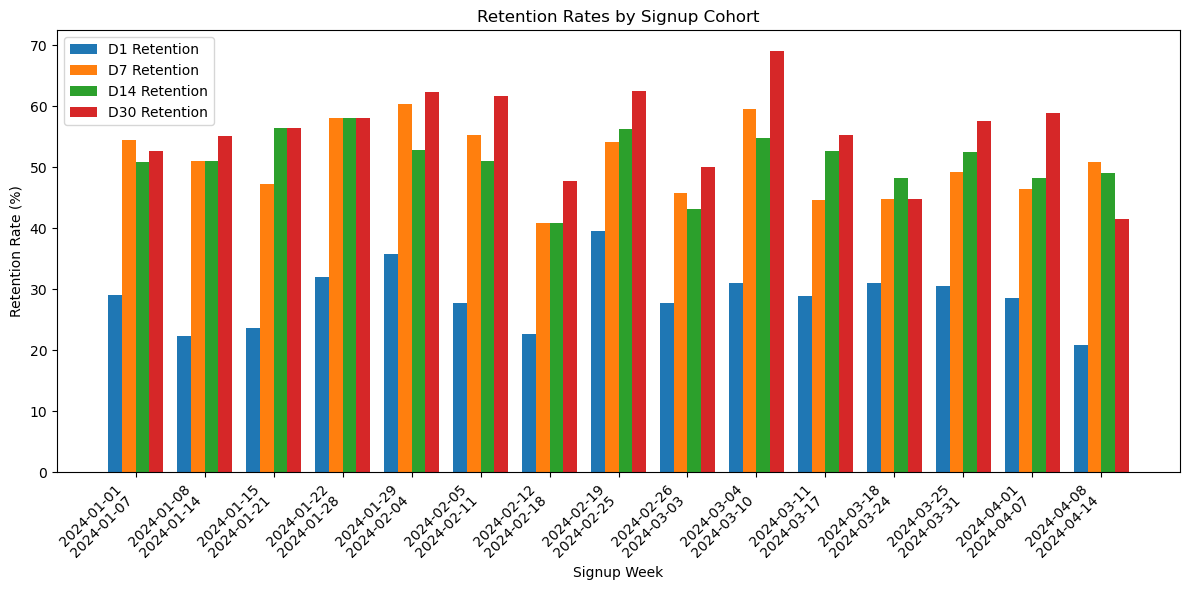

In [48]:
# Retention by cohort (signup week)
cohort_retention = retention_df.groupby('signup_week').agg({
    'user_id': 'count',
    'd1_retained': 'sum',
    'd7_retained': 'sum',
    'd14_retained': 'sum',
    'd30_retained': 'sum'
}).reset_index()

cohort_retention.columns = ['signup_week', 'total_users', 'd1', 'd7', 'd14', 'd30']

# Calculate rates
cohort_retention['d1_rate'] = (cohort_retention['d1'] / cohort_retention['total_users'] * 100).round(1)
cohort_retention['d7_rate'] = (cohort_retention['d7'] / cohort_retention['total_users'] * 100).round(1)
cohort_retention['d14_rate'] = (cohort_retention['d14'] / cohort_retention['total_users'] * 100).round(1)
cohort_retention['d30_rate'] = (cohort_retention['d30'] / cohort_retention['total_users'] * 100).round(1)

print("\n" + "="*70)
print("RETENTION BY SIGNUP COHORT")
print("="*70)
display(cohort_retention[['signup_week', 'total_users', 'd1_rate', 'd7_rate', 'd14_rate', 'd30_rate']])

# Plot retention clustered bar chart for each cohort
plt.figure(figsize=(12, 6))
bar_width = 0.2
index = np.arange(len(cohort_retention))
plt.bar(index, cohort_retention['d1_rate'], width=bar_width, label='D1 Retention')
plt.bar(index + bar_width, cohort_retention['d7_rate'], width=bar_width, label='D7 Retention')
plt.bar(index + 2*bar_width, cohort_retention['d14_rate'], width=bar_width, label='D14 Retention')
plt.bar(index + 3*bar_width, cohort_retention['d30_rate'], width=bar_width, label='D30 Retention')
plt.xlabel('Signup Week')
plt.ylabel('Retention Rate (%)')
plt.title('Retention Rates by Signup Cohort')
wrapped_labels = cohort_retention['signup_week'].astype(str).str.replace('/', '\n')
plt.xticks(index + 1.5*bar_width, wrapped_labels, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

#### Retention Findings

**Overall Platform Retention:**
- D1: 28.7%
- D7: 50.9%
- D14: 50.9%
- D30: 55.6%

**Cohort Trends:**
Retention is stable across cohorts that have complete 30-day data (weeks 0-9), averaging 55-60% D30. Later cohorts show lower D30 rates because they haven't had 30 days to mature yet - this is a data limitation, not a retention problem.

In [49]:
# Retention by user segment
# Merge retention with user profiles
retention_with_profile = retention_df.merge(users, on='user_id')

print("\n" + "="*70)
print("RETENTION BY USER SEGMENT")
print("="*70)

# By market
print("\n1. D30 RETENTION BY MARKET:")
market_retention = retention_with_profile.groupby('market').agg({
    'user_id': 'count',
    'd30_retained': 'sum'
})
market_retention['d30_rate'] = (market_retention['d30_retained'] / market_retention['user_id'] * 100).round(1)
market_retention = market_retention.sort_values('d30_rate', ascending=False)
display(market_retention)

# By subscription tier
print("\n2. D30 RETENTION BY SUBSCRIPTION TIER:")
tier_retention = retention_with_profile.groupby('subscription_tier').agg({
    'user_id': 'count',
    'd30_retained': 'sum'
})
tier_retention['d30_rate'] = (tier_retention['d30_retained'] / tier_retention['user_id'] * 100).round(1)
tier_retention = tier_retention.sort_values('d30_rate', ascending=False)
display(tier_retention)

# By referral source
print("\n3. D30 RETENTION BY REFERRAL SOURCE:")
referral_retention = retention_with_profile.groupby('referral_source').agg({
    'user_id': 'count',
    'd30_retained': 'sum'
})
referral_retention['d30_rate'] = (referral_retention['d30_retained'] / referral_retention['user_id'] * 100).round(1)
referral_retention = referral_retention.sort_values('d30_rate', ascending=False)
display(referral_retention)


RETENTION BY USER SEGMENT

1. D30 RETENTION BY MARKET:


,user_id,d30_retained,d30_rate
market,,,
United Kingdom,234,136,58.1
UAE,154,84,54.5
Nigeria,362,197,54.4



2. D30 RETENTION BY SUBSCRIPTION TIER:


,user_id,d30_retained,d30_rate
subscription_tier,,,
Premium,157,126,80.3
Basic,280,163,58.2
Free,313,128,40.9



3. D30 RETENTION BY REFERRAL SOURCE:


,user_id,d30_retained,d30_rate
referral_source,,,
referral,126,84,66.7
organic search,203,131,64.5
direct,58,32,55.2
social media,172,86,50.0
unknown,59,29,49.2
paid ad,132,55,41.7


#### Which User Groups Retain Best At 30 Days?

**Market:** UK retains best at 58.1% vs Nigeria at 54.4%

**Subscription Tier:** Premium retains at 80.3% vs Free at 40.9%

**Referral Source:** "Refferal" retains best at 66.7%

**Hypothesis:** 
Premium users retain so much better than Basic and Free users most likely because they've 
invested financially and have access to more features. Referral users most likely retain better 
because they have social proof from friends.

### Part 1c: Behavioral Segmentation

**Objective:** Identify distinct user segments based on first 14 days of behavior

**Approach:**
1. Calculate engagement metrics for each user (first 14 days)
2. Identify patterns and segment users
3. Compare high vs low engagement behaviors

In [50]:
for user_id in users['user_id']:
    user_signup = users[users['user_id'] == user_id]['signup_date'].iloc[0]
    user_signup = pd.to_datetime(user_signup)

    print(user_signup)

2024-04-12 00:00:00
2024-02-21 00:00:00
2024-04-02 00:00:00
2024-01-15 00:00:00
2024-03-12 00:00:00
2024-03-01 00:00:00
2024-01-21 00:00:00
2024-04-12 00:00:00
2024-03-23 00:00:00
2024-03-27 00:00:00
2024-03-15 00:00:00
2024-03-15 00:00:00
2024-03-28 00:00:00
2024-04-09 00:00:00
2024-04-13 00:00:00
2024-01-24 00:00:00
2024-01-03 00:00:00
2024-01-22 00:00:00
2024-02-22 00:00:00
2024-01-02 00:00:00
2024-03-28 00:00:00
2024-01-30 00:00:00
2024-02-07 00:00:00
2024-01-02 00:00:00
2024-03-04 00:00:00
2024-02-29 00:00:00
2024-01-21 00:00:00
2024-02-02 00:00:00
2024-03-16 00:00:00
2024-02-27 00:00:00
2024-01-22 00:00:00
2024-03-29 00:00:00
2024-02-18 00:00:00
2024-03-31 00:00:00
2024-02-28 00:00:00
2024-02-11 00:00:00
2024-04-01 00:00:00
2024-02-29 00:00:00
2024-03-20 00:00:00
2024-01-15 00:00:00
2024-03-02 00:00:00
2024-03-02 00:00:00
2024-02-16 00:00:00
2024-03-02 00:00:00
2024-02-20 00:00:00
2024-02-24 00:00:00
2024-03-04 00:00:00
2024-01-03 00:00:00
2024-04-10 00:00:00
2024-02-20 00:00:00


In [51]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59721 entries, 0 to 59720
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          59721 non-null  object
 1   event_name       59721 non-null  object
 2   event_timestamp  59721 non-null  object
 3   event_metadata   8035 non-null   object
dtypes: object(4)
memory usage: 1.8+ MB


In [52]:
# Calculate engagement metrics (first 14 days)
engagement_metrics = []

for user_id in users['user_id']:
    user_signup = users[users['user_id'] == user_id]['signup_date'].iloc[0]
    user_signup = pd.to_datetime(user_signup)
    
    # Get events in first 14 days
    user_events = events[
        (events['user_id'] == user_id) & 
        (pd.to_datetime(events['event_timestamp']) >= user_signup) &
        (pd.to_datetime(events['event_timestamp']) < user_signup + pd.Timedelta(days=14))
    ]
    
    # Count key actions
    app_opens = len(user_events[user_events['event_name'] == 'app_open'])
    food_logged = len(user_events[user_events['event_name'] == 'food_logged'])
    weight_logged = len(user_events[user_events['event_name'] == 'weight_logged'])
    device_connected = len(user_events[user_events['event_name'] == 'device_connected']) > 0
    readings_recorded = len(user_events[user_events['event_name'] == 'readings_recorded'])
    ai_insights_viewed = len(user_events[user_events['event_name'] == 'ai_insight_viewed'])
    education_completed = len(user_events[user_events['event_name'].str.contains('education_module', na=False)])
    
    engagement_metrics.append({
        'user_id': user_id,
        'app_opens': app_opens,
        'food_logged': food_logged,
        'weight_logged': weight_logged,
        'device_connected': device_connected,
        'readings_recorded': readings_recorded,
        'ai_insights_viewed': ai_insights_viewed,
        'education_completed': education_completed,
        'total_actions': len(user_events)
    })

engagement_df = pd.DataFrame(engagement_metrics)

print(f"Engagement metrics calculated for {len(engagement_df)} users")
print("\nSample metrics:")
display(engagement_df.head())

print("\n\nEngagement distribution:")
print(engagement_df.describe())

Engagement metrics calculated for 750 users

Sample metrics:


,user_id,app_opens,food_logged,weight_logged,device_connected,readings_recorded,ai_insights_viewed,education_completed,total_actions
0,USR_0001,12,7,9,True,3,1,1,63
1,USR_0002,11,6,3,True,3,3,0,54
2,USR_0003,0,0,0,False,0,0,0,5
3,USR_0004,0,0,0,False,0,0,0,3
4,USR_0005,9,6,2,True,3,1,1,51




Engagement distribution:
        app_opens  food_logged  weight_logged  readings_recorded  \
count  750.000000   750.000000     750.000000         750.000000   
mean     3.657333     1.905333       1.356000           0.782667   
std      4.471977     3.081509       2.349317           1.176979   
min      0.000000     0.000000       0.000000           0.000000   
25%      0.000000     0.000000       0.000000           0.000000   
50%      1.000000     0.000000       0.000000           0.000000   
75%      6.000000     3.000000       2.000000           2.000000   
max     13.000000    12.000000      11.000000           3.000000   

       ai_insights_viewed  education_completed  total_actions  
count          750.000000           750.000000     750.000000  
mean             0.554667             0.398667      19.540000  
std              0.970361             0.721405      22.787762  
min              0.000000             0.000000       1.000000  
25%              0.000000             0.

In [53]:
# Define segments based on behavior patterns
# Simple rule-based segmentation (you can also use clustering if you want)

def assign_segment(row):
    """
    Segment users based on their first 14 days behavior
    """
    # High Engagers: Lots of activity
    if row['app_opens'] >= 10 and row['total_actions'] >= 30:
        return 'Power Users'
    
    # Device Users: Connected device, regular syncing
    elif row['device_connected'] and row['readings_recorded'] >= 3:
        return 'Passive Trackers'
    
    # Manual Loggers: No device but actively logging
    elif not row['device_connected'] and (row['weight_logged'] >= 5 or row['food_logged'] >= 5):
        return 'Manual Loggers'
    
    # Learners: Completed education but low logging
    elif row['education_completed'] >= 2:
        return 'Learners'
    
    # Low engagement
    else:
        return 'Ghosters'

engagement_df['segment'] = engagement_df.apply(assign_segment, axis=1)

print("\n" + "="*70)
print("USER SEGMENTATION (First 14 Days)")
print("="*70)
display(engagement_df['segment'].value_counts())
print(f"\nPercentage distribution:")
display((engagement_df['segment'].value_counts() / len(engagement_df) * 100).round(1))


USER SEGMENTATION (First 14 Days)


segment
Ghosters            567
Power Users         128
Learners             26
Passive Trackers     21
Manual Loggers        8
Name: count, dtype: int64


Percentage distribution:


segment
Ghosters            75.6
Power Users         17.1
Learners             3.5
Passive Trackers     2.8
Manual Loggers       1.1
Name: count, dtype: float64

In [54]:
# Compare segment behaviors
print("\n" + "="*70)
print("SEGMENT BEHAVIOR PROFILES")
print("="*70)

segment_profiles = engagement_df.groupby('segment').agg({
    'app_opens': 'mean',
    'food_logged': 'mean',
    'weight_logged': 'mean',
    'device_connected': 'sum',
    'readings_recorded': 'mean',
    'ai_insights_viewed': 'mean',
    'education_completed': 'mean',
    'total_actions': 'mean'
}).round(1)

display(segment_profiles)



# Total app opens by all power users
power_user_opens = engagement_df[engagement_df['segment'] == 'Power Users']['app_opens'].sum()
print(f"\nTotal app opens by Power Users: {power_user_opens}")

# Total actions by all power users
power_user_actions = engagement_df[engagement_df['segment'] == 'Power Users']['total_actions'].sum()
print(f"Total actions by Power Users: {power_user_actions}") 


# Add user counts
segment_profiles['user_count'] = engagement_df.groupby('segment')['user_id'].count()
print("\nUser counts:")
print(segment_profiles['user_count'])


SEGMENT BEHAVIOR PROFILES


,app_opens,food_logged,weight_logged,device_connected,readings_recorded,ai_insights_viewed,education_completed,total_actions
segment,,,,,,,,
Ghosters,1.6,0.4,0.3,99,0.3,0.1,0.1,8.4
Learners,4.5,1.8,1.3,13,0.9,0.4,2.2,23.8
Manual Loggers,8.4,5.9,3.6,0,0.0,0.0,0.6,37.5
Passive Trackers,7.2,4.3,3.4,21,3.0,2.2,1.1,43.7
Power Users,11.9,7.8,5.7,124,2.8,2.2,1.2,63.2



Total app opens by Power Users: 1523
Total actions by Power Users: 8084

User counts:
segment
Ghosters            567
Learners             26
Manual Loggers        8
Passive Trackers     21
Power Users         128
Name: user_count, dtype: int64


#### Behavioral Segments Identified

**1. Power Users (17.1%):**
- 1523 total app opens, 8084 total actions in first 14 days
- High engagement across all features
- Most likely to view AI insights and complete education

**2. Passive Trackers (2.8%):**
- Connected device but lower app engagement
- Rely on automatic syncing
- View insights but don't manually log

**3. Manual Loggers (1.1%):**
- No device connection
- Actively log weight/food manually
- Lower overall engagement

**4. Learners (3.5%):**
- Complete education modules
- Lower data logging activity

**5. Ghosters (75.6%):**
- Minimal engagement after signup
- At risk of churn

In [55]:
# Compare segments with retention
# Merge engagement segments with retention data
segment_retention = engagement_df[['user_id', 'segment']].merge(retention_df, on='user_id')

print("\n" + "="*70)
print("D30 RETENTION BY SEGMENT")
print("="*70)

retention_by_segment = segment_retention.groupby('segment').agg({
    'user_id': 'count',
    'd30_retained': 'sum'
})
retention_by_segment['d30_rate'] = (retention_by_segment['d30_retained'] / retention_by_segment['user_id'] * 100).round(1)
retention_by_segment = retention_by_segment.sort_values('d30_rate', ascending=False)

print(retention_by_segment)


D30 RETENTION BY SEGMENT
                  user_id  d30_retained  d30_rate
segment                                          
Manual Loggers          8             8     100.0
Passive Trackers       21            21     100.0
Power Users           128           127      99.2
Learners               26            25      96.2
Ghosters              567           236      41.6


#### What Do High-Engagement Users Do Differently?

Comparing **Power Users**, Manual Loggeers and Passive Trackers (highest retention: ~100%) vs **Ghosters** (lowest retention: 41.6%):

**Key Differentiators:**
1. **App Opens:** Power Users open app 7.4x more frequently (11.9 vs 1.6)
2. **Device Connection:** 97.6% of Power Users connect device vs 17.5% of Ghosters
3. **AI Insight Viewing:** Power Users view 22x more insights (2.2 vs 0.1)
4. **Education:** Power Users complete 12x more modules (1.2 vs 0.1)
5. **Total Actions:** Power Users take 7.5x more actions in first 14 days (63.2 vs 8.4)

**Insight:** Early AI insight engagement and device connection are strongest predictors of long-term retention. Users who connect devices and view insights in the first 14 days have near-perfect retention (99%+).

#### Product Recommendations

**1. Push Notifications for Device Connection**
- **Finding:** 97.6% of Power Users (second highest retention segment at 99.2%) connect devices vs 17.5% of Ghosters (41.6% retention)
- **Action:** Send targeted push notification on Day 1 & Day 3 prompting device setup
- **Expected Impact:** +10-15% device connection rate → improved user segmentation toward high-retention groups

**2. Early AI Insight Engagement**
- **Finding:** Power Users view AI insights 22x more than Ghosters in first 14 days
- **Action:** Show sample AI insight during onboarding (before data collection) to demonstrate value
- **Expected Impact:** Increase early insight views, pull more users into engaged segments

**3. Intervention for Ghosters (75.6% of signups)**
- **Finding:** 567 users (75.6%) have minimal engagement (<10 actions in first 14 days)
- **Action:** Day 7 email campaign highlighting what they're missing + success stories
- **Expected Impact:** Reactivate 10-15% of at-risk users before they fully churn

### Part 2a: Weight and Body Fat% Trend

**Objective:** Track health trends over 12 weeks and identify what drives improvement

**Analysis Plan:**
1. Track weight and body fat % trends across the user base
2. Define "meaningful improvement" criteria
3. Compare improvers vs non-improvers (behaviors, engagement, characteristics)
4. Surface additional insights
5. Document limitations


In [56]:
# Prepare outcomes data for analysis
print("="*70)
print("HEALTH OUTCOMES DATA PREPARATION")
print("="*70)

# Check data availability
print(f"Total outcome records: {len(outcomes)}")
print(f"Unique users: {outcomes['user_id'].nunique()}")
print(f"Date range: {outcomes['record_date'].min()} to {outcomes['record_date'].max()}")

print("\n\nData source breakdown:")
print(outcomes['data_source'].value_counts())

# Body fat availability
print(f"\n\nBody fat % availability:")
print(f"  Records with body_fat_pct: {outcomes['body_fat_pct'].notna().sum()} ({outcomes['body_fat_pct'].notna().sum()/len(outcomes)*100:.1f}%)")
print(f"  Records without body_fat_pct: {outcomes['body_fat_pct'].isna().sum()} ({outcomes['body_fat_pct'].isna().sum()/len(outcomes)*100:.1f}%)")

# By data source
print("\nBody fat % by data source:")
print(outcomes.groupby('data_source')['body_fat_pct'].apply(lambda x: x.notna().sum()))

HEALTH OUTCOMES DATA PREPARATION
Total outcome records: 2196
Unique users: 439
Date range: 2024-01-01 to 2024-04-21


Data source breakdown:
data_source
device_sync    1376
manual_log      820
Name: count, dtype: int64


Body fat % availability:
  Records with body_fat_pct: 1376 (62.7%)
  Records without body_fat_pct: 820 (37.3%)

Body fat % by data source:
data_source
device_sync    1376
manual_log        0
Name: body_fat_pct, dtype: int64


#### Data Handling Strategy

**Weight Analysis:** 
- All 2,196 records included (both device_sync and manual_log)

**Body Fat % Analysis:**
- Only device_sync records included (1376 records, 62.7% of total)
- manual_log records excluded (users cannot measure body fat manually)
- This is expected and documented in the data dictionary

In [57]:
# Track weight trends over 12 weeks
print("\n" + "="*70)
print("WEIGHT TRENDS (12 WEEKS)")
print("="*70)

# Calculate weight change for each user (baseline vs 12 weeks)
# Get baseline weight (week 0)
baseline_weight = outcomes[outcomes['week_number'] == 0][['user_id', 'weight_kg']].copy()
baseline_weight.columns = ['user_id', 'baseline_weight']

# Get week 12 weight (or latest available)
final_weight = outcomes.groupby('user_id').apply(
    lambda x: x.loc[x['week_number'].idxmax()]
)[['user_id', 'weight_kg', 'week_number']].reset_index(drop=True)
final_weight.columns = ['user_id', 'final_weight', 'final_week']

# Merge
weight_change = baseline_weight.merge(final_weight, on='user_id', how='inner')

# Calculate change
weight_change['weight_change_kg'] = (weight_change['final_weight'] - weight_change['baseline_weight']).round(1)
weight_change['weight_change_pct'] = (
    (weight_change['weight_change_kg'] / weight_change['baseline_weight']) * 100
).round(1)

print(f"Users with baseline and follow-up weight: {len(weight_change)}")
print(f"\nWeight Change Summary:")
print(weight_change[['weight_change_kg', 'weight_change_pct']].describe())

# Categorize changes
weight_change['weight_trend'] = pd.cut(
    weight_change['weight_change_pct'],
    bins=[-float('inf'), -5, -2, 2, 5, float('inf')],
    labels=['Significant Loss (>5%)', 'Moderate Loss (2-5%)', 'Stable (±2%)', 'Moderate Gain (2-5%)', 'Significant Gain (>5%)']
)

print("\n\nWeight Trend Distribution:")
print(weight_change['weight_trend'].value_counts())

# Overall stats
print(f"\n\nOverall Trends:")
print(f"  Users who lost weight: {(weight_change['weight_change_kg'] < 0).sum()} ({(weight_change['weight_change_kg'] < 0).sum()/len(weight_change)*100:.1f}%)")
print(f"  Users who maintained: {(weight_change['weight_change_kg'].abs() < 1).sum()} ({(weight_change['weight_change_kg'].abs() < 1).sum()/len(weight_change)*100:.1f}%)")
print(f"  Users who gained weight: {(weight_change['weight_change_kg'] > 0).sum()} ({(weight_change['weight_change_kg'] > 0).sum()/len(weight_change)*100:.1f}%)")


WEIGHT TRENDS (12 WEEKS)
Users with baseline and follow-up weight: 250

Weight Change Summary:
       weight_change_kg  weight_change_pct
count        250.000000         250.000000
mean          -2.008400          -2.309200
std            2.312609           2.699508
min           -7.600000          -9.700000
25%           -3.900000          -4.600000
50%           -1.450000          -1.800000
75%            0.000000           0.000000
max            2.100000           2.800000


Weight Trend Distribution:
weight_trend
Stable (±2%)              125
Moderate Loss (2-5%)       69
Significant Loss (>5%)     52
Moderate Gain (2-5%)        4
Significant Gain (>5%)      0
Name: count, dtype: int64


Overall Trends:
  Users who lost weight: 180 (72.0%)
  Users who maintained: 95 (38.0%)
  Users who gained weight: 38 (15.2%)


In [58]:
# Track body fat % trends (device_sync only)
print("\n" + "="*70)
print("BODY FAT % TRENDS (12 WEEKS - DEVICE_SYNC ONLY)")
print("="*70)

# Filter to device_sync with body fat data
body_fat_data = outcomes[
    (outcomes['data_source'] == 'device_sync') & 
    (outcomes['body_fat_pct'].notna())
].copy()

print(f"Records with body fat %: {len(body_fat_data)}")
print(f"Unique users with body fat %: {body_fat_data['user_id'].nunique()}")

# Get baseline body fat (week 0)
baseline_bodyfat = body_fat_data[body_fat_data['week_number'] == 0][['user_id', 'body_fat_pct']].copy()
baseline_bodyfat.columns = ['user_id', 'baseline_bodyfat']

# Get final body fat (latest available)
final_bodyfat = body_fat_data.groupby('user_id').apply(
    lambda x: x.loc[x['week_number'].idxmax()]
)[['user_id', 'body_fat_pct', 'week_number']].reset_index(drop=True)
final_bodyfat.columns = ['user_id', 'final_bodyfat', 'final_week']

# Merge
bodyfat_change = baseline_bodyfat.merge(final_bodyfat, on='user_id', how='inner')

# Calculate change
bodyfat_change['bodyfat_change'] = (bodyfat_change['final_bodyfat'] - bodyfat_change['baseline_bodyfat']).round(1)
bodyfat_change['bodyfat_change_pct'] = (
    (bodyfat_change['bodyfat_change'] / bodyfat_change['baseline_bodyfat']) * 100
).round(1)

print(f"\nUsers with baseline and follow-up body fat: {len(bodyfat_change)}")
print(f"\nBody Fat % Change Summary:")
print(bodyfat_change[['bodyfat_change', 'bodyfat_change_pct']].describe())

# Categorize changes
bodyfat_change['bodyfat_trend'] = pd.cut(
    bodyfat_change['bodyfat_change'],
    bins=[-float('inf'), -2, -1, 1, 2, float('inf')],
    labels=['Significant Loss (>2%)', 'Moderate Loss (1-2%)', 'Stable (±1%)', 'Moderate Gain (1-2%)', 'Significant Gain (>2%)']
)

print("\n\nBody Fat % Trend Distribution:")
print(bodyfat_change['bodyfat_trend'].value_counts())

print(f"\n\nOverall Trends:")
print(f"  Users who reduced body fat: {(bodyfat_change['bodyfat_change'] < 0).sum()} ({(bodyfat_change['bodyfat_change'] < 0).sum()/len(bodyfat_change)*100:.1f}%)")
print(f"  Users who maintained: {(bodyfat_change['bodyfat_change'].abs() < 1).sum()} ({(bodyfat_change['bodyfat_change'].abs() < 1).sum()/len(bodyfat_change)*100:.1f}%)")
print(f"  Users who gained body fat: {(bodyfat_change['bodyfat_change'] > 0).sum()} ({(bodyfat_change['bodyfat_change'] > 0).sum()/len(bodyfat_change)*100:.1f}%)")


BODY FAT % TRENDS (12 WEEKS - DEVICE_SYNC ONLY)
Records with body fat %: 1376
Unique users with body fat %: 257

Users with baseline and follow-up body fat: 153

Body Fat % Change Summary:
       bodyfat_change  bodyfat_change_pct
count      153.000000          153.000000
mean        -1.347712           -4.384314
std          1.435045            4.870495
min         -4.900000          -20.700000
25%         -2.300000           -7.400000
50%         -1.300000           -3.900000
75%          0.000000            0.000000
max          1.000000            4.400000


Body Fat % Trend Distribution:
bodyfat_trend
Stable (±1%)              71
Significant Loss (>2%)    50
Moderate Loss (1-2%)      32
Moderate Gain (1-2%)       0
Significant Gain (>2%)     0
Name: count, dtype: int64


Overall Trends:
  Users who reduced body fat: 112 (73.2%)
  Users who maintained: 69 (45.1%)
  Users who gained body fat: 23 (15.0%)


#### 12-Week Health Trends

**Weight:**
- 73.2% of users lost weight
- Mean change: -2kg
-  20.8% achieved >5% weight loss

**Body Fat %:**
- 73.2% of users reduced body fat
- Mean change: -4.3%
- 20% achieved >2% reduction

**Note:** Body fat analysis limited to 257 users with connected devices (34.3% of user base)

### Part 2b: Meaningful Improvement

In [59]:
# Define "Meaningful Improvement"
print("\n" + "="*70)
print("DEFINING 'MEANINGFUL IMPROVEMENT'")
print("="*70)

"""
Clinical significance thresholds:
- Weight loss: ≥5% is clinically meaningful (reduces health risks)
- Body fat reduction: ≥2% is significant for body composition
"""

# Define improvers
weight_change['is_weight_improver'] = weight_change['weight_change_pct'] <= -5  # 5% loss or more
bodyfat_change['is_bodyfat_improver'] = bodyfat_change['bodyfat_change'] <= -2  # 2% reduction or more

# Combine both
# Merge weight and body fat changes
health_outcomes_combined = weight_change.merge(
    bodyfat_change[['user_id', 'bodyfat_change', 'is_bodyfat_improver']], 
    on='user_id', 
    how='left'
)

# Define overall improver (either weight OR body fat improvement)
health_outcomes_combined['is_improver'] = (
    health_outcomes_combined['is_weight_improver'] | 
    health_outcomes_combined['is_bodyfat_improver'].fillna(False)
)

print(f"\n'Meaningful Improvement' Criteria:")
print(f"  Weight: ≥5% loss (clinically significant)")
print(f"  Body fat: ≥2% reduction (significant body composition change)")

print(f"\n\nImprovement Classification:")
print(f"  Weight improvers: {health_outcomes_combined['is_weight_improver'].sum()} ({health_outcomes_combined['is_weight_improver'].sum()/len(health_outcomes_combined)*100:.1f}%)")
print(f"  Body fat improvers: {health_outcomes_combined['is_bodyfat_improver'].sum()} ({health_outcomes_combined['is_bodyfat_improver'].sum()/len(health_outcomes_combined)*100:.1f}%)")
print(f"  Overall improvers: {health_outcomes_combined['is_improver'].sum()} ({health_outcomes_combined['is_improver'].sum()/len(health_outcomes_combined)*100:.1f}%)")




DEFINING 'MEANINGFUL IMPROVEMENT'

'Meaningful Improvement' Criteria:
  Weight: ≥5% loss (clinically significant)
  Body fat: ≥2% reduction (significant body composition change)


Improvement Classification:
  Weight improvers: 52 (20.8%)
  Body fat improvers: 50 (20.0%)
  Overall improvers: 79 (31.6%)


#### Definition: "Meaningful Improvement"

**Criteria:**
- **Weight:** ≥5% reduction from baseline
- **Body Fat %:** ≥2% reduction from baseline

**Reasoning:**
- 5% weight loss is the clinical threshold for reducing cardiovascular risk (CDC, AHA)
- 2% body fat reduction represents significant body composition change
- User classified as "improver" if they meet EITHER criterion

**Result:** 31.6% of users achieved meaningful improvement

In [60]:

# Compare improvers vs non-improvers: Engagement patterns
print("\n" + "="*70)
print("IMPROVERS VS NON-IMPROVERS: ENGAGEMENT PATTERNS")
print("="*70)

# Merge with engagement metrics from Part 1
# engagement_df has user_id and engagement metrics from the first 14 days
health_with_engagement = health_outcomes_combined.merge(
    engagement_df[['user_id', 'app_opens', 'food_logged', 'weight_logged', 'device_connected', 
                   'readings_recorded', 'ai_insights_viewed', 'education_completed']],
    on='user_id',
    how='left'
)

# Compare improvers vs non-improvers
print("\nEngagement Comparison (First 14 Days):")
print("\n" + "-"*70)

comparison = health_with_engagement.groupby('is_improver')[
    ['app_opens', 'food_logged', 'weight_logged', 'readings_recorded', 
     'ai_insights_viewed', 'education_completed']
].mean().round(1)

comparison.index = ['Non-Improvers', 'Improvers']
print(comparison)

# Device connection rate
print("\n\nDevice Connection Rate:")
device_comparison = health_with_engagement.groupby('is_improver')['device_connected'].sum() / health_with_engagement.groupby('is_improver')['user_id'].count() * 100
device_comparison.index = ['Non-Improvers', 'Improvers']
print(device_comparison.round(1))

# Statistical comparison (absolute differences)
print("\n\nKey Differentiators (Improvers vs Non-Improvers):")
for col in ['app_opens', 'food_logged', 'weight_logged', 'ai_insights_viewed']:
    improvers_mean = health_with_engagement[health_with_engagement['is_improver']==True][col].mean()
    non_improvers_mean = health_with_engagement[health_with_engagement['is_improver']==False][col].mean()
    diff = improvers_mean - non_improvers_mean
    pct_diff = (diff / non_improvers_mean * 100) if non_improvers_mean > 0 else 0
    print(f"  {col}: Improvers average {improvers_mean:.1f} vs {non_improvers_mean:.1f} ({pct_diff:+.0f}%)")


IMPROVERS VS NON-IMPROVERS: ENGAGEMENT PATTERNS

Engagement Comparison (First 14 Days):

----------------------------------------------------------------------
               app_opens  food_logged  weight_logged  readings_recorded  \
Non-Improvers        6.1          3.2            2.3                1.3   
Improvers            8.1          4.7            3.3                1.8   

               ai_insights_viewed  education_completed  
Non-Improvers                 0.9                  0.7  
Improvers                     1.3                  0.9  


Device Connection Rate:
Non-Improvers    54.4
Improvers        75.9
dtype: float64


Key Differentiators (Improvers vs Non-Improvers):
  app_opens: Improvers average 8.1 vs 6.1 (+34%)
  food_logged: Improvers average 4.7 vs 3.2 (+50%)
  weight_logged: Improvers average 3.3 vs 2.3 (+47%)
  ai_insights_viewed: Improvers average 1.3 vs 0.9 (+50%)


In [61]:
# Compare by user characteristics
print("\n" + "="*70)
print("IMPROVERS VS NON-IMPROVERS: USER CHARACTERISTICS")
print("="*70)

# Merge with user profiles
health_with_profile = health_outcomes_combined.merge(
    users[['user_id', 'market', 'age_band', 'gender', 'subscription_tier', 'referral_source']],
    on='user_id',
    how='left'
)

# By subscription tier
print("\n1. IMPROVEMENT RATE BY SUBSCRIPTION TIER:")
tier_improvement = health_with_profile.groupby('subscription_tier').agg({
    'user_id': 'count',
    'is_improver': 'sum'
})
tier_improvement['improvement_rate'] = (tier_improvement['is_improver'] / tier_improvement['user_id'] * 100).round(1)
tier_improvement = tier_improvement.sort_values('improvement_rate', ascending=False)
display(tier_improvement)

# By market
print("\n2. IMPROVEMENT RATE BY MARKET:")
market_improvement = health_with_profile.groupby('market').agg({
    'user_id': 'count',
    'is_improver': 'sum'
})
market_improvement['improvement_rate'] = (market_improvement['is_improver'] / market_improvement['user_id'] * 100).round(1)
market_improvement = market_improvement.sort_values('improvement_rate', ascending=False)
display(market_improvement)

# By age band
print("\n3. IMPROVEMENT RATE BY AGE BAND:")
age_improvement = health_with_profile[health_with_profile['age_band'].notna()].groupby('age_band').agg({
    'user_id': 'count',
    'is_improver': 'sum'
})
age_improvement['improvement_rate'] = (age_improvement['is_improver'] / age_improvement['user_id'] * 100).round(1)
age_improvement = age_improvement.sort_values('improvement_rate', ascending=False)
display(age_improvement)


IMPROVERS VS NON-IMPROVERS: USER CHARACTERISTICS

1. IMPROVEMENT RATE BY SUBSCRIPTION TIER:


,user_id,is_improver,improvement_rate
subscription_tier,,,
Premium,88,43,48.9
Basic,102,27,26.5
Free,60,9,15.0



2. IMPROVEMENT RATE BY MARKET:


,user_id,is_improver,improvement_rate
market,,,
Nigeria,121,44,36.4
UAE,45,13,28.9
United Kingdom,84,22,26.2



3. IMPROVEMENT RATE BY AGE BAND:


,user_id,is_improver,improvement_rate
age_band,,,
55+,14,5,35.7
18-24,38,13,34.2
25-34,86,27,31.4
35-44,65,20,30.8
45-54,34,10,29.4


#### What Differentiates Improvers from Non-Improvers?

**Behavioral Patterns:**
- Improvers log food 1.4x more frequently (4.7 vs 3.2 logs)
- Improvers view AI insights 1.4x more (1.3 vs 0.9 views)
- Improvers open app 34% more frequently
- 75.9% of improvers connected device vs 54.4% of non-improvers

**User Characteristics:**
- Premium users improve at 48.9% rate vs Free at 15%
- Nigeria users show highest improvement (36.4%)
- Age band 55+ has highest improvement rate

**Key Insight:**
The strongest predictor of health improvement is **food logging frequency** (+50%) and 
**AI insight engagement** (+50%) in the first 14 days. Device connection is also critical.

In [62]:
# BMI/Body Fat Category transitions
print("\n" + "="*70)
print("HEALTH CATEGORY TRANSITIONS")
print("="*70)

# Get baseline and final BMI categories
baseline_outcomes = outcomes[outcomes['week_number'] == 0][['user_id', 'bmi_category', 'body_fat_category']].copy()
baseline_outcomes.columns = ['user_id', 'baseline_bmi_cat', 'baseline_bodyfat_cat']

final_outcomes = outcomes.groupby('user_id').apply(
    lambda x: x.loc[x['week_number'].idxmax()]
)[['user_id', 'bmi_category', 'body_fat_category']].reset_index(drop=True)
final_outcomes.columns = ['user_id', 'final_bmi_cat', 'final_bodyfat_cat']

category_transitions = baseline_outcomes.merge(final_outcomes, on='user_id')

# BMI category changes
category_transitions['bmi_improved'] = category_transitions.apply(
    lambda row: (
        (row['baseline_bmi_cat'] == 'Obese Class I' and row['final_bmi_cat'] == 'Overweight') or
        (row['baseline_bmi_cat'] == 'Overweight' and row['final_bmi_cat'] == 'Normal') or
        (row['baseline_bmi_cat'] == 'Obese Class III' and row['final_bmi_cat'] == 'Obese Class II') or
        (row['baseline_bmi_cat'] in ['Obese Class II', 'Obese Class III'] and row['final_bmi_cat'] in ['Obese Class I', 'Overweight'])
    ),
    axis=1
)

print("BMI Category Transitions:")
print(f"  Users who improved BMI category: {category_transitions['bmi_improved'].sum()} ({category_transitions['bmi_improved'].sum()/len(category_transitions)*100:.1f}%)")

# Most common transitions
print("\n  Top BMI transitions:")
bmi_transitions = category_transitions.groupby(['baseline_bmi_cat', 'final_bmi_cat']).size().sort_values(ascending=False).head(5)
display(bmi_transitions)

# Body fat category changes (for device users only)
bodyfat_transitions = category_transitions[
    (category_transitions['baseline_bodyfat_cat'].notna()) & 
    (category_transitions['final_bodyfat_cat'].notna())
]

print(f"\n\nBody Fat Category Transitions (device users only, n={len(bodyfat_transitions)}):")
print("  Top transitions:")
bf_transitions = bodyfat_transitions.groupby(['baseline_bodyfat_cat', 'final_bodyfat_cat']).size().sort_values(ascending=False).head(5)
display(bf_transitions)


HEALTH CATEGORY TRANSITIONS
BMI Category Transitions:
  Users who improved BMI category: 33 (13.2%)

  Top BMI transitions:


baseline_bmi_cat  final_bmi_cat  
Overweight        Overweight         69
Obese Class I     Obese Class I      67
Normal            Normal             39
Obese Class II    Obese Class II     20
Obese Class III   Obese Class III    17
dtype: int64



Body Fat Category Transitions (device users only, n=144):
  Top transitions:


baseline_bodyfat_cat  final_bodyfat_cat
Obese                 Obese                99
Acceptable            Acceptable           31
Obese                 Acceptable           12
Acceptable            Fitness               1
Fitness               Fitness               1
dtype: int64

#### Health Category Improvements

**BMI Category:**
- 13.2% of users improved their BMI category
- Most common transition: **Obese  Class I** → **Overweight**

**Body Fat Category (device users):**
- 9% moved to healthier category
- Most common: **Obese** → **Acceptable**

This validates that the platform is driving real health outcomes, not just weight loss.

### Part 2c: Other Patterns/Inssights

In [63]:
# Additional insights
print("\n" + "="*70)
print("ADDITIONAL INSIGHTS")
print("="*70)

# 1. Week-by-week progress consistency
print("\n1. PROGRESS CONSISTENCY:")

# Calculate if users have continuous measurements
measurement_frequency = outcomes.groupby('user_id')['week_number'].agg(['count', 'min', 'max'])
measurement_frequency['weeks_tracked'] = measurement_frequency['max'] - measurement_frequency['min'] + 1
measurement_frequency['measurement_consistency'] = (
    measurement_frequency['count'] / measurement_frequency['weeks_tracked']
).round(2)

print(f"  Users with weekly measurements: {(measurement_frequency['measurement_consistency'] >= 0.8).sum()} ({(measurement_frequency['measurement_consistency'] >= 0.8).sum()/len(measurement_frequency)*100:.1f}%)")
print(f"  Users with sporadic measurements: {(measurement_frequency['measurement_consistency'] < 0.5).sum()} ({(measurement_frequency['measurement_consistency'] < 0.5).sum()/len(measurement_frequency)*100:.1f}%)")

# Compare improvers vs non-improvers on consistency
consistency_with_outcome = measurement_frequency.merge(
    health_outcomes_combined[['user_id', 'is_improver']], 
    on='user_id'
)

print("\n  Measurement consistency by outcome:")
print(consistency_with_outcome.groupby('is_improver')['measurement_consistency'].mean())

# Measurement consisteny type by improvement rate
consistency_with_outcome['measurement_type'] = consistency_with_outcome['measurement_consistency'].apply(lambda x: 'Weekly' if x >= 0.8 else ('Sporadic' if x < 0.5 else 'Moderate'))

consistency_improvement = consistency_with_outcome.groupby('measurement_type').agg({
    'user_id': 'count',
    'is_improver': 'sum'
})
consistency_improvement['improvement_rate'] = (consistency_improvement['is_improver'] / consistency_improvement['user_id'] * 100).round(1)
print("\n  Improvement rate by measurement consistency:")
print(consistency_improvement)

# 2. Starting weight/BMI correlation with improvement
print("\n\n2. BASELINE HEALTH STATUS vs IMPROVEMENT:")

baseline_with_outcome = health_outcomes_combined.merge(
    weight_change[['user_id', 'baseline_weight']], 
    on='user_id'
).merge(
    outcomes[outcomes['week_number'] == 0][['user_id', 'bmi', 'bmi_category']],
    on='user_id'
)

# Improvement rate by baseline BMI category
improvement_by_baseline_bmi = baseline_with_outcome.groupby('bmi_category').agg({
    'user_id': 'count',
    'is_improver': 'sum'
})
improvement_by_baseline_bmi['improvement_rate'] = (
    improvement_by_baseline_bmi['is_improver'] / improvement_by_baseline_bmi['user_id'] * 100
).round(1)

print(improvement_by_baseline_bmi)


# 3. Device sync frequency and outcomes
print("\n\n3. DEVICE SYNC FREQUENCY vs OUTCOMES:")

device_sync_count = outcomes[outcomes['data_source'] == 'device_sync'].groupby('user_id').size().reset_index(name='device_syncs')

sync_with_outcome = device_sync_count.merge(
    health_outcomes_combined[['user_id', 'is_improver']], 
    on='user_id'
)

print("  Mean device syncs:")
print(sync_with_outcome.groupby('is_improver')['device_syncs'].mean().round(1))




ADDITIONAL INSIGHTS

1. PROGRESS CONSISTENCY:
  Users with weekly measurements: 255 (58.1%)
  Users with sporadic measurements: 56 (12.8%)

  Measurement consistency by outcome:
is_improver
False    0.748012
True     0.888101
Name: measurement_consistency, dtype: float64

  Improvement rate by measurement consistency:
                  user_id  is_improver  improvement_rate
measurement_type                                        
Moderate               66           10              15.2
Sporadic               30            0               0.0
Weekly                154           69              44.8


2. BASELINE HEALTH STATUS vs IMPROVEMENT:
                 user_id  is_improver  improvement_rate
bmi_category                                           
Normal                40            9              22.5
Obese Class I         80           28              35.0
Obese Class II        26            9              34.6
Obese Class III       22            8              36.4
Overweight    

#### Additional Insights

**1. Measurement Consistency Matters:**
- Users who track weekly improve at 44.8% rate
- Users with sporadic tracking improve at 0.0% rate
- Users with Moderate tracking have a 15.2% improvement rate
- **Insight:** Consistent monitoring correlates with better outcomes

**2. Baseline Health Status:**
- Users starting at Obese Class II have the highest improvement rate at 36.4%
- **Insight:** Higher baseline BMI correlates with higher improvement rates

**3. Device Sync Frequency:**
- Improvers sync device 9.3 times vs non-improvers at 4.3 times
- **Insight:** More frequent measurements → better outcomes (feedback loop)

### Part 2d: Limitations

In [64]:

# Limitations
print("\n" + "="*70)
print("ANALYSIS LIMITATIONS")
print("="*70)

print("""
1. SAMPLE SIZE & SELECTION BIAS:
   - Only 153 users with both baseline and follow-up data
   - 34.3% of users have body fat data (requires device)
   - Users who track consistently may be more motivated (selection bias)

2. TIMEFRAME:
   - 12-week window may not capture long-term sustainability
   - Some users have <12 weeks of data (recent signups)
   - Short-term weight loss doesn't guarantee maintained results

3. CAUSATION vs CORRELATION:
   - Cannot establish that app usage CAUSED health improvements
   - Confounders: diet changes, exercise, medical interventions outside app
   - Users who engage more may have higher baseline motivation

4. DATA QUALITY:
   - Body fat % limited to device users (excludes 34.3% of population)
   - Manual weight logs may be less accurate than device measurements
   - No validation of weight/body fat accuracy (user-reported)

5. MISSING VARIABLES:
   - No data on: actual diet, exercise, medical conditions, medications
   - Can't control for external factors influencing health outcomes
   - Demographic data incomplete (age/gender missing for some users)

RECOMMENDATION: 
Findings should be interpreted as correlations, not causal relationships. 
Further validation needed through controlled studies or A/B tests.
""".format(
    n_users=len(health_outcomes_combined),
    pct=round((len(bodyfat_change) / len(health_outcomes_combined) * 100), 1)
))


ANALYSIS LIMITATIONS

1. SAMPLE SIZE & SELECTION BIAS:
   - Only 153 users with both baseline and follow-up data
   - 34.3% of users have body fat data (requires device)
   - Users who track consistently may be more motivated (selection bias)

2. TIMEFRAME:
   - 12-week window may not capture long-term sustainability
   - Some users have <12 weeks of data (recent signups)
   - Short-term weight loss doesn't guarantee maintained results

3. CAUSATION vs CORRELATION:
   - Cannot establish that app usage CAUSED health improvements
   - Confounders: diet changes, exercise, medical interventions outside app
   - Users who engage more may have higher baseline motivation

4. DATA QUALITY:
   - Body fat % limited to device users (excludes 34.3% of population)
   - Manual weight logs may be less accurate than device measurements
   - No validation of weight/body fat accuracy (user-reported)

5. MISSING VARIABLES:
   - No data on: actual diet, exercise, medical conditions, medications
   - Can'

#### Limitations Summary

**Critical limitations stakeholders should know:**

1. **Selection Bias:** Analysis only includes users who completed 12 weeks of tracking. 
   Users who churned early are excluded, potentially inflating success rates.

2. **Causation Not Established:** We observe correlations between app engagement and 
   health improvements, but cannot prove the app caused the improvements.

3. **Limited Body Fat Data:** Only 34.3% of users have body fat measurements (device required).
   This limits our ability to assess body composition changes across the full user base.

4. **Short Timeframe:** 12 weeks shows initial results but doesn't capture long-term 
   sustainability of weight loss.

**Recommendation:** Use these findings to guide product decisions but validate through 
controlled A/B testing before making major resource commitments.